# A First Monte Carlo Uncertainty Quantification Demo: Longitudinal Strength &rarr; Peak Force

## Why treat progressive damage analysis probabilistically?

NB1 built a single-element model and asked one question: given *this* longitudinal tensile
strength, at *this* boundary condition, what load does the ply carry before damage starts?
That is a deterministic question, and it has a single deterministic answer. But, in general, the longitudinal
tensile strength is a property that composite manufacturers and researchers measure over many nominally identical coupons, and the measured values scatter. Fiber diameter and alignment vary within a tow, resin content and cure quality vary across a panel, and voids and other manufacturing defects appear unevenly; all of it changes
the load at which a given ply actually fails, even for material that came off the same
production line with the same nominal layup. [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020) survey this directly: composite structures are subject to significant, well-documented
material and geometric variability, and a stochastic (probabilistic) treatment of that
variability is needed to assess structural reliability with any real confidence. A purely
deterministic analysis, run once at a single nominal property value, is silent on how
sensitive its answer is to the scatter that property actually has in practice.

**The idea this notebook builds.** If $X_T$ is uncertain, the honest way to carry
that uncertainty through the model is not to guess a single "conservative" value and rerun
NB1's deterministic model once, but to describe $X_T$'s scatter mathematically, as a
**random variable**, and run the *same* deterministic model many times, once per plausible value of $X_T$. The result is not a single peak force, but a whole **distribution** of peak forces. Only once that distribution is in hand can questions like "how likely is an unusually low peak force?" or "what design value should I
allow for?" be answered with actual evidence instead of an educated guess. That is Monte
Carlo uncertainty quantification (UQ), and this notebook builds the smallest possible working
version of it: one uncertain input, one deterministic Abaqus model, run repeatedly. The end goal of this process is to obtain a trustworthy picture of how $F_{peak}$ is distributed: mean, spread, and, crucially, the low-percentile behavior that governs whether a structure survives.

**Learning objectives**

- Turn NB1's verified single-element model into one input of a Monte Carlo uncertainty
  quantification (UQ) pipeline, by treating its fiber tensile strength $X_T$ as a random
  variable instead of a fixed constant.
- Treat the *output* of the model, $F_{peak}$, as the actual quantity of interest and read a chosen percentile off its distribution once that distribution is characterized.
- Understand what a **standard error** actually is, use it to decide how many Monte Carlo samples are enough for a *parametric* estimator, and see explicitly what this a-priori sizing shortcut assumes.
- Build a complete, working Monte Carlo pipeline end to end: draw random inputs, run each one
  through the real Abaqus model, and save the full force-displacement and damage history from
  every single run.
- See why a histogram is a poor tool for looking at a sampled distribution's shape, and how KDE
  fixes that, using the leave-one-out cross-validated bandwidth-selection criterion used in
  [Catalanotti (2022)](https://doi.org/10.1016/j.compositesa.2022.107238).
- Estimate a low percentile of the *output* three different ways: the parametric plug-in
  formula, the distribution-free order statistic, and kernel density estimation (KDE), and
  understand why the three disagree and what that disagreement means.

This notebook is deliberately minimal: one random input, one output, plain Monte Carlo, no surrogate models, no variance-reduction tricks, and (for reasons explained as they come up) only linear element formulation (`nlgeom=OFF`). The goal is a fully working, verified UQ pipeline on the simplest possible case. Everything else, including the `nlgeom=ON` comparison, is the natural next step, taken up in NB3.

## Part 1 &ndash; The uncertain input and its exact closed-form consequence

### Why longitudinal strength &rarr; peak force, and why that pairing is special

NB1 built a single-element model of a ply loaded in pure fiber-direction tension, and
verified that damage initiates in the fiber-tension mode the instant the effective stress
$\hat\sigma_{11}$ reaches the longitudinal tensile strength $X_T$, in other words, the moment $F_{ft}=1$ in Hashin's criteria. Up to that instant the model is still perfectly
elastic: no stiffness has degraded yet, so the reaction force is still climbing linearly with applied displacement.

Once that criterion is met, damage initiates and the model enters the softening branch of its constitutive law. This means that the reaction force has a peak at the instant of initiation, and then it starts to decrease as the softening branch takes over. We call this peak
reaction force $F_{peak}$. This is an important quantity to know, because it is the maximum
load the ply can carry before damage starts to degrade its stiffness.

In the small-strain approximation, the peak reaction force is simply equal to the
longitudinal tensile strength $X_T$ times the cross-sectional area of the ply $A$:

$$
F_{peak} = X_T \cdot A.
$$

If $A$ is treated as a constant, this is a **linear** relationship between the input $X_T$
and the output $F_{peak}$.

**Why this pairing is worth choosing for a first UQ demo.** A linear input-output map is the
one case where the *exact* shape of the output distribution can be written down directly from
the shape of the input distribution, with no simulation needed at all. That gives this notebook something a
more complicated model would not have: an independent, closed-form answer to check the entire
Monte Carlo pipeline against.

### From a fixed constant to a random variable

NB1 treated $X_T$ as a fixed number, $990$ MPa, because a deterministic model needs exactly
one value for every input. The introduction above argued that this is not really how $X_T$
behaves: it scatters from coupon to coupon. Turning that qualitative fact into something a
model can actually use takes two separate ideas, each worth stating on its own before they
get combined.

**Idea 1: an uncertain quantity can be modeled as a random variable.** A random variable is,
informally, a quantity whose value is not fixed in advance but is instead drawn according to
some rule of chance: rolling a die, measuring the height of the next person to walk through
a door, or here, measuring the tensile strength of the next composite coupon to be pulled to
failure ([Rubinstein & Kroese, 2016](https://doi.org/10.1002/9781118631980), &sect;1.4). Writing
$X_T$ as a random variable is a modeling choice: instead of pretending every ply has exactly
the strength written on a datasheet, it acknowledges directly that repeating "manufacture a
ply and measure its strength" gives a different number each time, and builds that fact into
the model instead of hiding it.

**Idea 2: a random variable is described by a probability distribution.** Saying "$X_T$ is a
random variable" on its own says nothing about *which* values are likely and which are not. That information is carried by the random variable's **probability distribution**, a mathematical object that assigns likelihood to every value (or range of values) the random
variable could take.

**Putting the two ideas together.** Once $X_T$ is a random variable with a distribution, so
is $F_{peak}$: it is computed *from* $X_T$ (via $F_{peak}=X_T\cdot A$ in the small-strain
case, or via the full nonlinear Abaqus model in general), so a different draw of $X_T$
produces a different $F_{peak}$, and $F_{peak}$ inherits a probability distribution of its
own, shifted and reshaped by whatever the $X_T\to F_{peak}$ mapping happens to do to it.
That output distribution is what this notebook is actually after. It is the object that lets a later question like "how low could $F_{peak}$ plausibly be?" be answered with a number instead of a guess.

**Why a percentile, not just the mean.** Once $F_{peak}$ has a distribution, the most natural
summary to reach for is its mean, but the mean is the wrong number to design against. A
structure might not fail because the strength of its *typical* ply is not enough; it might fail
because *some* ply, somewhere, turns out to be on the weak side of the scatter, and that unlucky ply is exactly
the one the design has to survive. That is why, alongside the mean, it is important to track a **percentile** $Q_p$ of the distribution of the quantity of interest &ndash; the value that a fraction $p$ of the population falls at or below &ndash; and to treat a low
percentile (the 1st, 5th, or 10th, say) as the important target.

### Choosing a distribution for $X_T$

**What a normal distribution is.** The normal (or Gaussian) distribution is the familiar
symmetric, bell-shaped distribution, fully described by just two numbers: a **mean** $\mu$
(where the bell is centered &ndash; the most likely value, and also the average of infinitely many
draws) and a **standard deviation** $\sigma$ (how wide the bell is &ndash; how far a typical draw
strays from $\mu$). A convenient way to express scatter *relative* to the mean, used
throughout this notebook, is the **coefficient of variation**, $\text{CoV}=\sigma/\mu$. For instance, a
CoV of 5% means the typical draw is within about 5% of the mean, regardless of what the mean
itself happens to be.

**Why normal, here.** This is a deliberate simplification, not a claim that it is the most
physically accurate choice: a normal distribution is fully specified by two familiar numbers,
its properties are the simplest to work with in closed form, and it lets this first UQ demo focus on building and
verifying the *pipeline* &ndash; the sampling, the Abaqus loop, the reconstruction, the statistical
checks &ndash; without also having to justify a more elaborate distributional model at the same
time. A more defensible choice for a strength property specifically is discussed at the end
of this section.

**What a probability density function is.** A random variable's distribution is often drawn
as a **probability density function (PDF)**, that is to say a curve $f(x)$ such that the *area* under the
curve between two values $a$ and $b$ equals the probability that a draw of the random variable lands between $a$ and $b$. The height of the curve at a single point is not itself a probability (a single exact value has zero probability for a continuous random variable like
$X_T$); only areas under the curve are. The total area under any PDF is exactly 1, since the
random variable has to take *some* value. For the normal distribution, the PDF has the
closed-form expression

$$
f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),
$$

plotted below for the specific $\mu,\sigma$ this notebook uses.

**The numbers used here:**

$$
X_T \sim \mathcal{N}(\mu=990\ \text{MPa},\ \sigma \approx 49.5\ \text{MPa}), \qquad
\text{CoV} = \sigma/\mu = 5\%.
$$

$\mu=990$ MPa is the longitudinal tensile strength of a fiberglass-reinforced epoxy ply reported by [Nelson et al. (2017)](https://doi.org/10.5194/wes-2-653-2017) and already used in NB1. Nelson et al. report only this point value, with no scatter statistics at all. The 5% CoV is not sourced from them. Instead, it is chosen as a representative order of magnitude for composite strength scatter, informed by the review of stochastic FRP composite properties in [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020), who compile CoV values reported across the composites literature for this kind of strength property. Treat $\sigma=49.5$ MPa as this notebook's own illustrative modeling choice, not a measured value for this specific material.

**A caveat worth naming, and a forward pointer.** A normal distribution technically assigns
some (tiny) probability to $X_T<0$, which is unphysical, as a material cannot have negative
strength. At a 5% CoV this negative tail is negligible enough to ignore for this demonstration, but the honest statement is that the normal distribution *permits* it while the true physical distribution of a strength property does not. This is exactly the kind of
gap [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020)
flag when they discuss distribution selection for composite properties, and it is why the
standard distributional choice for a brittle-fiber tensile strength specifically is not the
normal but the [Weibull (1951)](https://doi.org/10.1115/1.4010337) distribution: it is derived
from *weakest-link theory* (a fiber is only as strong as its weakest flaw, so extreme-value
statistics, not averaging statistics, govern its strength scatter), is bounded below by zero,
and is the standard choice used in stochastic-composites literature. This notebook keeps the normal distribution for its analytical convenience and defers the switch to Weibull to a later notebook, once the Monte Carlo pipeline itself is verified.

The cell below defines $\mu$ and $\sigma$ in code and plots the theoretical PDF this choice implies.

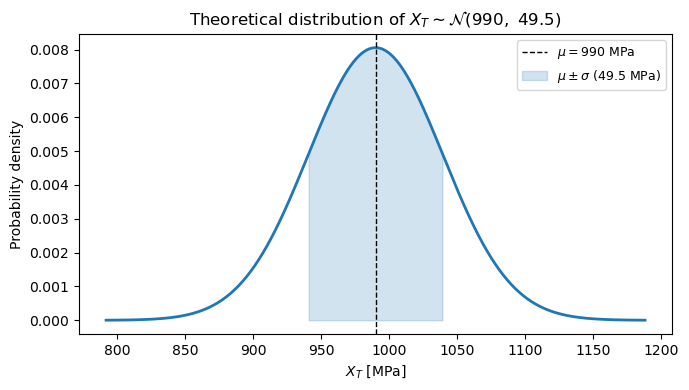

In [1]:
import matplotlib.pyplot as plt
import numpy as np

MU = 990.0     # MPa, fiber tensile strength X_T - Nelson, Riddle & Cairns (2017), Table 2
SIGMA = 49.5   # MPa, 5% CoV - illustrative scatter, NOT from Nelson et al. (see above)


# Define the normal probability density function (PDF) for a given mean and standard deviation.
def gaussian_pdf(x, mu, sigma):
    """Normal probability density function f(x; mu, sigma) - used throughout this notebook
    to overlay the theoretical distribution on top of sampled/simulated data. Implements the
    closed-form expression given above directly (no scipy dependency needed for something
    this simple)."""
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


# x_grid spans +-4 standard deviations around the mean, which comfortably covers essentially
# all of the distribution's probability mass. Reused for every later plot in this notebook
# that overlays the theoretical PDF on top of sampled/simulated data, so every such plot uses
# the same x-range and is directly comparable to this one.
x_grid = np.linspace(MU - 4 * SIGMA, MU + 4 * SIGMA, 400)

# Plot the theoretical PDF of X_T ~ N(990, 49.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_grid, gaussian_pdf(x_grid, MU, SIGMA), color="C0", lw=2)
ax.axvline(MU, color="k", ls="--", lw=1, label=f"$\\mu={MU:.0f}$ MPa")
# Shade the +-1 sigma band: by the 68-95-99.7 rule for a normal distribution, this shaded
# area is about 68% of the total area under the curve, i.e. P(mu - sigma < X_T < mu + sigma).
ax.fill_between(x_grid, gaussian_pdf(x_grid, MU, SIGMA),
                where=(x_grid >= MU - SIGMA) & (x_grid <= MU + SIGMA),
                color="C0", alpha=0.2, label=f"$\\mu\\pm\\sigma$ ({SIGMA:.1f} MPa)")
# Label the axes and add a title and legend. Use LaTeX math formatting for the labels.
ax.set_xlabel("$X_T$ [MPa]")
ax.set_ylabel("Probability density")
ax.set_title(r"Theoretical distribution of $X_T \sim \mathcal{N}(990,\ 49.5)$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The plot above is the theoretical PDF this notebook samples from throughout: symmetric, centered
on $\mu=990$ MPa, with the shaded band showing where about 68% of the probability mass sits
($\mu\pm\sigma$). At this CoV the curve is visibly nowhere near zero MPa, which is consistent with the
caveat above that the normal distribution's unphysical negative tail is negligible here, even
though it is technically nonzero.

### The output distribution in the small-strain limit

$X_T$ now has a distribution, $X_T\sim\mathcal N(\mu, \sigma)$ with $\mu=990$ MPa and
$\sigma=49.5$ MPa. Because $F_{peak}=A\cdot X_T$ is a **linear transform** of $X_T$, its distribution can be written
down directly, with no sampling and no simulation at all:

$$
F_{peak} = A\cdot X_T \sim \mathcal{N}(A\mu,\ A\sigma).
$$

A linear transform of a Normal random variable is itself Normal, simply rescaled and
re-centered by the constant $A$ in our case. This is the payoff of choosing this particular,
deliberately simple input-output pairing for a first UQ demo: the *exact* output distribution
is available before a single Abaqus job runs.

**From a distribution to a percentile.** For a Normal random variable, the $p$-th percentile value $Q_p$ has the
closed form

$$
Q_p = \mu + z_p\,\sigma,
$$

where $z_p$ is the standard Normal distribution's own $p$-th percentile (where the standard Normal distribution is a Normal distribution with $\mu=0$ and $\sigma=1$, meaning that $z_p$ is a fixed number, independent of $\mu,\sigma$). Formally, $z_p$ is the value satisfying $\Phi(z_p)=p$ for the standard Normal cumulative distribution function $\Phi$. There is no closed-form expression for this inverse,
so the cell below evaluates it numerically, via `scipy.stats.norm.ppf`, for the three percentiles this notebook returns to later: 1%, 5%, and 10%.

In [2]:
from scipy.stats import norm

# z_p is the p-th percentile of the STANDARD normal distribution N(0,1): the value z such
# that Phi(z) = p, where Phi is the standard normal CDF. No closed form exists for this
# inverse ("probit" function), so it has to be evaluated numerically -
# scipy.stats.norm.ppf ("percent point function") does exactly that.
Z_P = {"1%": float(norm.ppf(0.01)), "5%": float(norm.ppf(0.05)), "10%": float(norm.ppf(0.10))}
z_p_labels = {p: p.replace("%", r"\%") for p in Z_P.keys()}  # LaTeX-escaped percent sign, for legend labels later

print(f"{'p':<6s}{'z_p':>8s}")
for p, z in Z_P.items():
    print(f"{p:<6s}{z:8.3f}")

p          z_p
1%      -2.326
5%      -1.645
10%     -1.282


Applying the same linear map to the percentile itself gives $F_{peak}$'s percentile directly: $Q_p(F_{peak}) = A\cdot Q_p(X_T) = A(\mu+z_p\sigma)$. No separate derivation is needed, because a percentile of a linearly-transformed Normal variable transforms exactly the same way the variable itself does. The cell below plots the three percentiles on top of the full PDF of $X_T$ and $F_{peak}$.

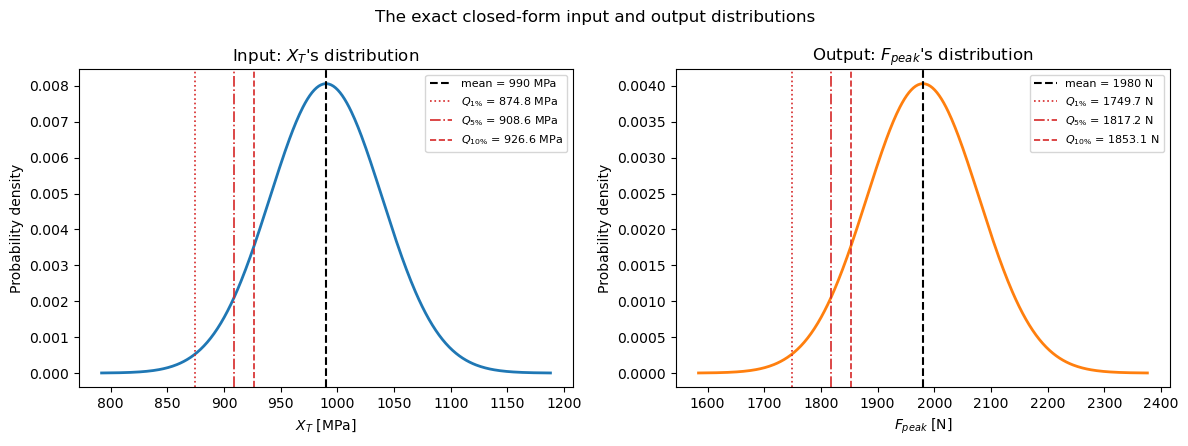

X_T:      mean=990.00 MPa, std=49.50 MPa, Q_1%=874.85 MPa, Q_5%=908.58 MPa, Q_10%=926.56 MPa
F_peak:   mean=1980.00 N, std=99.00 N, Q_1%=1749.69 N, Q_5%=1817.16 N, Q_10%=1853.13 N


In [3]:
# Cross-sectional area of the single-element model
A = 10.0 * 0.2  # mm^2 - gauge width (10 mm) times ply thickness (0.2 mm), both NB1's geometry

# The two analytical predictions this notebook will check the Monte Carlo campaign against:
# (1) the linear input-output map itself, and (2) the Gaussian output distribution it implies.
# Both follow directly from F_peak = A * X_T being a linear transform of a Normal random variable.
analytical_mean = A * MU     # N, predicted mean peak force
analytical_std = A * SIGMA   # N, predicted std of peak force

# Percentiles of X_T (input) and F_peak (output), both from the same closed form
# Q_p = mu + z_p*sigma (F_peak's version simply uses A*mu, A*sigma in place of mu, sigma).
x_t_percentiles = {p: MU + z * SIGMA for p, z in Z_P.items()}
f_peak_percentiles = {p: analytical_mean + z * analytical_std for p, z in Z_P.items()}

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot the theoretical PDF of X_T on the left subplot
axes[0].plot(x_grid, gaussian_pdf(x_grid, MU, SIGMA), color="C0", lw=2)
axes[0].axvline(MU, color="k", ls="--", lw=1.5, label=f"mean = {MU:.0f} MPa")
for (p, val), ls in zip(x_t_percentiles.items(), [":", "-.", "--"]):
    axes[0].axvline(val, color="C3", ls=ls, lw=1.2, label=f"$Q_{{{z_p_labels[p]}}}$ = {val:.1f} MPa")
axes[0].set_xlabel("$X_T$ [MPa]")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Input: $X_T$'s distribution")
axes[0].legend(fontsize=8)

# Plot the theoretical PDF of F_peak on the right subplot
f_grid = np.linspace(analytical_mean - 4 * analytical_std, analytical_mean + 4 * analytical_std, 400)
axes[1].plot(f_grid, gaussian_pdf(f_grid, analytical_mean, analytical_std), color="C1", lw=2)
axes[1].axvline(analytical_mean, color="k", ls="--", lw=1.5, label=f"mean = {analytical_mean:.0f} N")
for (p, val), ls in zip(f_peak_percentiles.items(), [":", "-.", "--"]):
    axes[1].axvline(val, color="C3", ls=ls, lw=1.2, label=f"$Q_{{{z_p_labels[p]}}}$ = {val:.1f} N")
axes[1].set_xlabel("$F_{peak}$ [N]")
axes[1].set_ylabel("Probability density")
axes[1].set_title(r"Output: $F_{peak}$'s distribution")
axes[1].legend(fontsize=8)

# Add a super-title for the entire figure and adjust layout to prevent overlap
fig.suptitle("The exact closed-form input and output distributions")
fig.tight_layout()
plt.show()

# Print the analytical mean, std, and percentiles for both X_T and F_peak in a formatted way
print(f"X_T:      mean={MU:.2f} MPa, std={SIGMA:.2f} MPa, " +
      ", ".join(f"Q_{p}={v:.2f} MPa" for p, v in x_t_percentiles.items()))
print(f"F_peak:   mean={analytical_mean:.2f} N, std={analytical_std:.2f} N, " +
      ", ".join(f"Q_{p}={v:.2f} N" for p, v in f_peak_percentiles.items()))

The two panels above are the same bell shape, only rescaled: the right panel is exactly the left one stretched (and shifted) by the constant $A=2\ \text{mm}^2$. Every percentile moves the same way, which is exactly the linear-map argument from the previous section made visible: each dashed line in the left panel (a percentile of $X_T$) has a partner in the right panel (the corresponding percentile of $F_{peak}$) at exactly $A$ times the position, and the printed numbers confirm it &ndash; $Q_{5\%}(X_T)=908.58$ MPa becomes $Q_{5\%}(F_{peak})=A\times908.58=1817.16$ N. The right-hand panel is the object the rest of this notebook is actually about: from here on, every histogram, every estimator, and every percentile the Monte Carlo campaign produces is checked against this one closed-form curve and the numbers printed underneath it.

**A colour convention, used consistently from here on.** The figure above already follows it: `C0` (blue) marks anything describing the *input* distribution, $X_T$; `C1` (orange) marks the *output* distribution, $F_{peak}$, in its empirical/simulated form (histograms, an empirical CDF, sampled force-displacement curves); `C3` (red) marks a percentile or point-estimate marker; and a black dashed line is always the analytical/true value, when one exists. One more colour joins this list once Part 5 introduces kernel density estimation: `C2` (green) marks anything *derived from* a KDE fit (its density curve, its own CDF, the cross-validation curve that chooses its bandwidth) &ndash; visually distinct from the raw empirical data (`C1`) it is estimated from.

### Why this closed form is the exception, not the rule

The way the entire distribution of $F_{peak}$ &mdash; mean, std, and every percentile &mdash; fell
straight out of $X_T$'s own distribution is not how things work in general. The moment the
input-output map is anything other than exactly linear &mdash; a real laminate, a model with more
than one uncertain property, or even this same model once `nlgeom=ON` introduces genuine
nonlinearity &mdash; there is no closed form left to write down. The only way to find out how
$F_{peak}$ is actually distributed is to draw a finite number of samples of the input
uncertain parameter $X_T$, run each one through the real (in this case, Abaqus) model, and
build up the output distribution empirically from the resulting set of simulated outputs. This is exactly the Monte Carlo approach and what we are going to introduce in the next section.

## Part 2 &ndash; How many samples do we need?

### From a closed form to Monte Carlo simulation

Executing a **Monte Carlo simulation** means drawing $N$ random samples of an uncertain input, run the same deterministic model once per sample, and treat the resulting $N$ simulated outputs as an empirical stand-in for the output's true
distribution [(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980). The idea
itself is simple; the question that actually decides whether it is useful is **how large $N$
needs to be**. In general this cannot be worked out ahead of time &mdash; there is no formula to
invert, because there is no formula for the output distribution to begin with &mdash; so $N$ has
to be judged from the simulation results themselves, by checking how much they change as more
samples are added.

**This notebook is the exception, and deliberately so.** Because $F_{peak}=A\cdot X_T$ is known to be an exactly linear map of a Normal random variable, the sample size $N$ can be derived analytically, from a target precision, *before* a single Abaqus job runs, something a general problem would not allow. The rest of this Part does exactly that, for the model run with a linear element formulation (`nlgeom=OFF`), the case NB1 verified matches the small-strain formulas this whole Part relies on.

### Monte Carlo estimates and their standard error

Given $N$ sampled values $X_1,\dots,X_N$ of a random variable (here, $N$ draws of $X_T$), a
**Monte Carlo estimate** of a summary quantity is simply that summary computed from the
finite sample instead of from the full population. The two estimators this notebook needs are
the sample mean and the sample standard deviation,

$$
\widehat\mu = \bar X = \frac{1}{N}\sum_{i=1}^N X_i, \qquad
\widehat\sigma = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (X_i-\bar X)^2}.
$$

Both are **unbiased**: their average value, over infinitely many repeated batches of $N$
samples, equals the true $\mu$ and $\sigma$ exactly
[(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980). This is *why*
$\widehat\sigma$ divides by $N-1$, not $N$ (Bessel's correction): dividing by $N$ would
systematically underestimate $\sigma$. This notebook uses `ddof=1` (the $N-1$ divisor) in
every `.std()` call for this reason.

Every time $N$ fresh samples are drawn, $\widehat\mu$ and $\widehat\sigma$ come out slightly
different. The **standard error (SE)** of an estimator is the standard deviation *of that
estimator itself*, across this hypothetical population of "repeat the whole experiment with a
fresh batch of $N$ samples". In other words, the standard error answers the question: *if this sampling procedure were run over and
over, how far would a typical run's estimate land from the true value?* Note the difference with $\sigma$, standard deviation of the population: $\sigma$ describes how far a *single* draw of $X_T$ strays from $\mu$, fixed
regardless of $N$; $SE$ describes how far a *summary statistic computed from $N$ draws*
strays from the truth, and it shrinks as $N$ grows. A **confidence interval** of an estimate $\widehat\ell$,
$\widehat\ell\pm k\cdot SE(\widehat\ell)$, turns that spread into a stated probability of
containing the truth. For an approximately Normal estimator, $k=2$ gives roughly a 95%
confidence level, meaning that 95% of repeated batches of $N$ samples would produce an interval that contains the true population parameter $\ell$. The 95% confidence interval is the one employed throughout this notebook.

### How fast do these estimates converge?

[Ahn & Fessler (2003)](https://web.eecs.umich.edu/~fessler/papers/files/tr/stderr.pdf) give
the standard error of both estimators above, for a sample drawn from $\mathcal N(\mu,\sigma)$:

$$
SE(\widehat\mu) = \frac{\sigma}{\sqrt N}, \qquad
SE(\widehat\sigma) \approx \frac{\sigma}{\sqrt{2(N-1)}} \quad (\text{large-}N\text{ approximation}).
$$

Both shrink like $1/\sqrt N$, the hallmark Monte Carlo convergence rate. To compare the
two, and to set a tolerance in the percentage terms engineers actually think in, this notebook
uses the **relative standard error**, $SE(\widehat\ell)/\ell$
[(Rubinstein & Kroese, 2016)](https://doi.org/10.1002/9781118631980):

$$
\text{relSE}(\widehat\mu) = \frac{\sigma}{\mu\sqrt N} = \frac{\text{CoV}}{\sqrt N}, \qquad
\text{relSE}(\widehat\sigma) \approx \frac{1}{\sqrt{2(N-1)}},
$$

where $\ell$ is the true value of the quantity being estimated.

In *absolute* terms $SE(\widehat\sigma)$ is smaller than $SE(\widehat\mu)$ for the same $N$
(by roughly $\sqrt2$), so it might seem like $\sigma$ should always be easier to pin down.
But $SE(\widehat\sigma)$ is measured *relative to $\sigma$ itself*, which in our case is about 20 times smaller than
$\mu$, so once both are expressed as *relative* errors the comparison flips: at $N=2$, $\text{relSE}(\widehat\mu)$ is already a modest 3.5%, while $\text{relSE}(\widehat\sigma)$ still exceeds 70%. **The scatter is generally the harder quantity to pin down, in relative
terms and, as the next section shows, it is the scatter that any low-percentile estimate depends on most.**

### The target: trusting the weak tail of $F_{peak}$'s distribution

The goal of this whole exercise is not "estimate $F_{peak}$'s mean well"; it is to
characterize $F_{peak}$'s distribution well enough that its **weak tail** can be trusted: the
low percentiles that tell a designer how bad an unlucky ply can plausibly be, which is exactly
the information a mean cannot provide. Concretely, that means setting a target relative standard error on a chosen percentile $Q_p$ of $F_{peak}$'s distribution:

$$
\text{relSE}\big(\widehat{Q_p}(F_{peak})\big) \le \text{target}.
$$

Because $F_{peak}=A\cdot X_T$ is an exactly linear map, a percentile of $F_{peak}$ is simply
$A$ times the same percentile of $X_T$, that is to say $Q_p(F_{peak})=A\cdot Q_p(X_T)$, and that same
scaling carries through to the estimator's standard error:

$$
\widehat{Q_p}(F_{peak}) = A\cdot\widehat{Q_p}(X_T)
\;\Longrightarrow\;
SE\big(\widehat{Q_p}(F_{peak})\big) = A\cdot SE\big(\widehat{Q_p}(X_T)\big)
\;\Longrightarrow\;
\text{relSE}\big(\widehat{Q_p}(F_{peak})\big) = \frac{A\cdot SE(\widehat{Q_p}(X_T))}{A\cdot Q_p(X_T)} = \text{relSE}\big(\widehat{Q_p}(X_T)\big).
$$

The constant $A$ cancels exactly out of the *relative* error. In practice, this means the
target can be set, and the required sample size derived, entirely in terms of $X_T$, so no
Abaqus run needed for this part of the analysis.

For a Normal population, **the plug-in percentile estimator** &mdash; the parametric estimator this Part sizes $N$ for, described in full once real data is in hand in Part 5 &mdash; is built from $\widehat\mu$ and $\widehat\sigma$ the same way the true percentile is built from $\mu$ and $\sigma$:

$$
\widehat{Q_p} = \widehat\mu + z_p\,\widehat\sigma.
$$

Any target percentile with $p<50\%$ has $z_p<0$, so $\widehat\sigma$ enters directly in the error calculation: even a *perfect* estimate of $\mu$ still leaves $Q_p$ off by $|z_p|$ times whatever error remains in $\widehat\sigma$, and the deeper into the tail $p$ sits, the
larger $|z_p|$ is, so the more that error gets amplified. That is the concrete reason $\widehat\sigma$ has to be sized on equal footing with $\widehat\mu$ below, not folded in as a secondary check.

### From the target to a required $N$

$\widehat{Q_p}=\widehat\mu+z_p\widehat\sigma$ combines two estimators linearly. To find its
standard error it helps to first go through **variance**, defined here simply as the square of
the standard error, $\mathrm{Var}\left(\widehat\ell\right) \equiv SE\left(\widehat\ell\right)^2$, or equivalently,
$SE\left(\widehat\ell\right)=\sqrt{\mathrm{Var}\left(\widehat\ell\right)}$. Nothing new is being assumed here, only a
name given to a squared quantity. The reason to detour through it at all is that **variances of
independent quantities add, while standard errors do not**: the square root of a sum is not the
sum of the square roots, $\sqrt{a+b}\neq\sqrt a+\sqrt b$. So the two error sources below are
combined in variance, and converted back to a standard error by a single square root at the very
end, not before.

For two random quantities $U,V$ and constants $a,b$, the variance of their linear combination is

$$
\mathrm{Var}(aU+bV) = a^2\mathrm{Var}(U) + b^2\mathrm{Var}(V) + 2ab\,\mathrm{Cov}(U,V),
$$

where $\mathrm{Cov}(U,V)$, the **covariance** of $U$ and $V$, measures how much the two move
together. It is positive if they tend to rise and fall together, zero if they are independent.
Four steps turn this general identity into $SE(\widehat{Q_p})$:

1. **Apply the identity** with $U=\widehat\mu$, $V=\widehat\sigma$, $a=1$, $b=z_p$ (matching
   $\widehat{Q_p}=\widehat\mu+z_p\widehat\sigma$):
   $$
   \mathrm{Var}(\widehat{Q_p}) = \mathrm{Var}(\widehat\mu) + z_p^2\,\mathrm{Var}(\widehat\sigma) + 2z_p\,\mathrm{Cov}(\widehat\mu,\widehat\sigma).
   $$
2. **Drop the covariance term.** For a sample drawn from a Normal population, $\bar X$ and
   $\widehat\sigma$ are independent
   [(Casella & Berger, 2024)](https://doi.org/10.1201/9781003456285), so
   $\mathrm{Cov}(\widehat\mu,\widehat\sigma)=0$ and the last term vanishes.
3. **Substitute $\mathrm{Var}=SE^2$ back in**, using the definition from the top of this section:
   $$
   SE(\widehat{Q_p})^2 = SE(\widehat\mu)^2 + z_p^2\,SE(\widehat\sigma)^2.
   $$
4. **Take the square root once, at the very end**, to get back to a standard error:
   $$
   SE(\widehat{Q_p}) = \sqrt{SE(\widehat\mu)^2 + z_p^2\,SE(\widehat\sigma)^2}.
   $$

This &mdash; adding the squared errors, then taking one square root &mdash; is what "combining in
quadrature" means, and it is exactly why $\widehat\sigma$'s error cannot simply be added to
$\widehat\mu$'s error directly.

Dividing through by $Q_p$ turns this into a relative error with two natural weights:

$$
\text{relSE}(\widehat{Q_p}) = \sqrt{\big(w_\mu\cdot\text{relSE}(\widehat\mu)\big)^2 + \big(w_\sigma\cdot\text{relSE}(\widehat\sigma)\big)^2},
\qquad
w_\mu=\frac{\mu}{Q_p},\quad w_\sigma=\frac{z_p\sigma}{Q_p},
$$

which fall straight out of dividing $Q_p=\mu+z_p\sigma$ by itself ($w_\mu+w_\sigma=1$). Both weights depend on which percentile is targeted, through $z_p$: a
deeper tail target (smaller $p$, more negative $z_p$) hands $\widehat\sigma$'s harder-to-pin-down relative error a larger weight, which is exactly why resolving a deeper
percentile costs more samples. The next cell shows the convergence of twice the relative standard error (corresponding to a 95% confidence interval) for the mean, the standard deviation, and the 1st, 5th, and 10th percentiles of $X_T$, and it calculates the sample size $N$ needed to hit either 5% or 1% target on each of those five quantities.

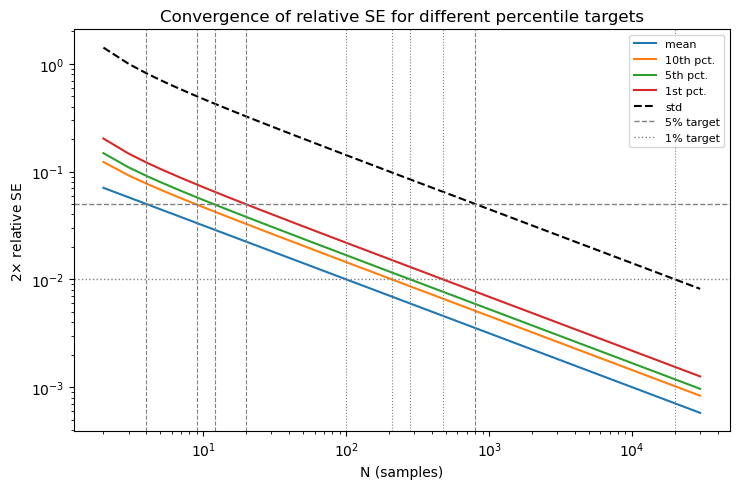

Required N for 2*relSE <= 5%, by target:
  mean           : N = 4
  10th pct.      : N = 9
  5th pct.       : N = 12
  1st pct.       : N = 20
  std            : N = 801

Required N for 2*relSE <= 1%, by target:
  mean           : N = 100
  10th pct.      : N = 209
  5th pct.       : N = 280
  1st pct.       : N = 476
  std            : N = 20001



In [4]:
K_CONF = 2.0        # k=2, the ~95% confidence-level convention used throughout this notebook
TARGET_RELS = [0.05, 0.01]  # error targets compared side by side below


def q_p(z_p):
    """Q_p = mu + z_p*sigma - the closed-form p-th percentile of X_T (and, via A*Q_p, of
    F_peak too)."""
    return MU + z_p * SIGMA


def relse_mean(N):
    """Relative SE of the sample mean: SE(mean)/mu = CoV/sqrt(N) (Ahn & Fessler, Sec. II-A)."""
    return (SIGMA / MU) / np.sqrt(N)


def relse_std(N):
    """Relative SE of the sample std: SE(std)/sigma ~ 1/sqrt(2*(N-1)) (Ahn & Fessler, Sec.
    II-C, eq. 3; valid for N > 10, undefined at N=1 since a sample std needs at least 2 points)."""
    return 1.0 / np.sqrt(2 * (N - 1))


def relse_q_p(N, z_p):
    """Relative SE of Q_p_hat for an arbitrary target z_p, combining the two SEs above in
    quadrature (see the derivation above)."""
    Qp = q_p(z_p)
    w_mu = MU / Qp
    w_sigma = z_p * SIGMA / Qp
    return np.hypot(w_mu * relse_mean(N), w_sigma * relse_std(N))


def required_n(z_p, target_rel, k=K_CONF, n_max=200_000):
    """Smallest N with k*relSE(Q_p_hat) <= target_rel, for the given target z_p."""
    n = 3
    while k * relse_q_p(n, z_p) > target_rel and n < n_max:
        n += 1
    return n


def required_n_std(target_rel, k=K_CONF, n_max=200_000):
    """Smallest N with k*relSE(std) <= target_rel - the sample size needed to pin down sigma
    itself to the same tolerance, on the same terms as required_n above pins down a
    percentile."""
    n = 3
    while k * relse_std(n) > target_rel and n < n_max:
        n += 1
    return n


# Four percentile targets compared on equal footing: the mean itself (z_p=0, i.e. Q_p=mu) and
# three lower-tail percentiles. Deeper into the tail (more negative z_p) should need a larger
# N, since sigma's weight w_sigma(z_p) grows with |z_p| (see the derivation above). Plain-text
# labels throughout (not a math symbol) so the printed tables below read in plain English.
TARGETS = {"mean": 0.0, "10th pct.": Z_P["10%"], "5th pct.": Z_P["5%"], "1st pct.": Z_P["1%"]}
LINESTYLES = {0.01: ":", 0.05: "--"}  # one linestyle per target tolerance, shared between the
                                       # plot's dashed/dotted lines and the printed tables below

N_grid = np.arange(2, 30_001)
fig, ax = plt.subplots(figsize=(7.5, 5))
for label, z_p in TARGETS.items():
    rel_se = K_CONF * np.array([relse_q_p(n, z_p) for n in N_grid])
    ax.loglog(N_grid, rel_se, label=label)

# The standard deviation's own relative SE, plotted the same way but NOT folded into any
# percentile estimator - this is the cost of pinning down the scatter itself, shown for
# comparison against every percentile curve above.
rel_se_std = K_CONF * np.array([relse_std(n) for n in N_grid])
ax.loglog(N_grid, rel_se_std, color="k", ls="--", label="std")

# required_n_by_target[target_rel][label] = smallest N hitting that target for that quantity,
# computed once for BOTH the 1% target this notebook commits to and a looser 5% target, so the
# plot and the printed tables below can show the effect of loosening the tolerance on its own,
# separately from the effect of moving to a deeper percentile.
required_n_by_target = {
    t: {label: required_n(z_p, t) for label, z_p in TARGETS.items()} for t in TARGET_RELS
}
required_n_std_by_target = {t: required_n_std(t) for t in TARGET_RELS}

for t in TARGET_RELS:
    ls = LINESTYLES[t]
    ax.axhline(t, color="gray", ls=ls, lw=1, label=f"{t:.0%} target")
    for n_req in required_n_by_target[t].values():
        ax.axvline(n_req, color="gray", ls=ls, lw=0.8)
    ax.axvline(required_n_std_by_target[t], color="gray", ls=ls, lw=0.8)

ax.set_xlabel("N (samples)")
ax.set_ylabel(f"{K_CONF:.0f}" + r"$\times$ relative SE")
ax.set_title("Convergence of relative SE for different percentile targets")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

for t in TARGET_RELS:
    print(f"Required N for {K_CONF:.0f}*relSE <= {t:.0%}, by target:")
    for label, n_req in required_n_by_target[t].items():
        print(f"  {label:15s}: N = {n_req}")
    print(f"  {'std':15s}: N = {required_n_std_by_target[t]}")
    print()

Two things stand out from the plot and the two tables above.

**Depth into the tail matters, but less than the tolerance does.** At the 1% target, the mean
needs only $N=100$; the 10th, 5th and 1st percentiles need $209$, $280$ and $476$ respectively.
Each deeper percentile costs more, because a deeper tail target has a larger $|z_p|$, which
hands $\widehat\sigma$'s harder-to-pin-down relative error a bigger weight in the quadrature sum
derived above. For instance, going all the way from the 10th percentile to the 1st costs about
2.3$\times$ more samples ($476/209$).

**Loosening the tolerance is a far bigger lever.** Relaxing the same 5th-percentile error target from
1% to 5% drops the requirement from $N=280$ to $N=12$, roughly $23\times$ fewer samples,
for an error target that is only $5\times$ looser. This is $\text{relSE}\propto 1/\sqrt N$ working in
reverse: $N\propto 1/\text{target}^2$, so a $5\times$ looser tolerance costs $5^2=25\times$ fewer
samples (the reason the two numbers, 23 and 25, are close but not identical is the two-term
quadrature sum, not a pure $1/\sqrt N$ law). **The practical lesson: when a Monte Carlo campaign
feels too expensive, ask first how tight the tolerance really needs to be, before assuming a
deeper or shallower percentile is the only lever available.**

The dashed std curve sits above every percentile curve at both targets, and at the 1% target
only crosses the target line at $N\approx20{,}001$. Indeed, the payoff of targeting one percentile
rather than the whole scatter is given by the fact that $\widehat{Q_p}$ blends the cheap-to-pin-down mean with
the expensive-to-pin-down std, weighted by how much of $Q_p$'s own value each one contributes.

**A caveat on the 5%-target row.** $N=4$ to $N=20$ are small enough that the *large-N* approximation formula
$SE(\widehat\sigma)\approx\sigma/\sqrt{2(N-1)}$ should not be trusted at face value there. That row is included to show the
*scaling* of cost with tolerance, not as an actual recommendation to run a 4-, 9-, 12- or 20-sample campaign.

**This notebook commits to the 5th percentile, $Q_{5\%}$, at the 1% target**, as its target to
characterize the tail of the input (and output) distribution. It sits deep enough into the tail
to matter for the "worst-case, not typical" framing motivated earlier, without needing the very
large $N$ the 1st percentile (or the std itself) would demand at the same tolerance. That choice
gives $N=280$.

**What this $N$ is actually sized for.** The derivation above sizes $N$ so that the *plug-in*
estimator $\widehat{Q_p}=\widehat\mu+z_p\widehat\sigma$ hits its target. This is a **parametric**
estimator, built from just two numbers, for a variable this notebook *chose* to make Normal. That
is a very specific, favorable case. Part 5 below estimates $F_{peak}$'s own 5th percentile three
different ways: the plug-in formula (matching how $N$ was sized, and, for `nlgeom=OFF`, provably
exact here since an exactly linear map of a Normal input is itself Normal), the distribution-free
order statistic (which assumes nothing about the shape of the output and is the estimator a real
problem, with no known closed form, would actually have to use), and a kernel density estimate.
The three will not agree exactly, and seeing *why* they differ is one of this notebook's main
points.

**Two more things worth keeping in mind about this choice.** First, both numbers &mdash; the 1%
tolerance and the 5th percentile &mdash; are illustrative, not derived from anything more
fundamental. A real study would size them from engineering judgement and, often, regulatory or
industry codes rather than analyst convenience: the composites industry, for instance, works with
**A-basis** and **B-basis** design allowables, defined as the 1st and 10th percentile respectively
(each itself estimated with 95% confidence, see [Catalanotti, 2022](https://doi.org/10.1016/j.compositesa.2022.107238)). Second, this whole a-priori derivation of $N$ only exists because a closed form for $F_{peak}$'s distribution is available in the first place. This is a genuine
special case, not the general situation. Exploiting it here is a deliberate choice: it lets this
notebook introduce standard error, confidence intervals, and quadrature combination on concrete,
checkable numbers, and it means the sample size can simply be fixed once and used, rather than
having to *monitor convergence* as samples are added one batch at a time and stop once the
estimate has stabilized. This is what a general problem, with no closed form to lean on, would
actually require, and what we are going to explore in the next notebook, for both `nlgeom` settings.

With both targets computed and compared, the cell below commits to the one this notebook
actually uses for the rest of Part 2 and beyond: the 1% tolerance on the 5th percentile, and the
$N$ it requires.

In [5]:
TARGET_REL = 0.01  # this notebook's committed target: 1% relative error on the 5th percentile
N = required_n_by_target[TARGET_REL]["5th pct."]  # -> N = 280, read straight out of the table above

### Does an actual random sample deliver this?

$N=280$ is what the theory says is needed for the *typical* behavior of the sampling
procedure, but it says nothing about how one particular, actually-drawn sequence behaves. The
cell below draws $N$ samples from three candidate seeds (2, 16, 90) and checks each one
directly against the $\pm1\%$ target on $\widehat{Q_{5\%}}$ at 95% confidence interval.

In [6]:
CANDIDATE_SEEDS = [2, 16, 90]
Z_5 = Z_P["5%"]
samples = {seed: np.random.default_rng(seed).normal(MU, SIGMA, N) for seed in CANDIDATE_SEEDS}

TARGET_Q5 = q_p(Z_5)  # the true, closed-form 5th percentile of X_T

print(f"{'seed':>6s}{'mean_hat':>12s}{'std_hat':>12s}{'Q5%_hat':>12s}{'Q5% err':>12s}")
for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    m, sd = s.mean(), s.std(ddof=1)
    q5_hat = m + Z_5 * sd
    err = (q5_hat - TARGET_Q5) / TARGET_Q5
    print(f"{seed:6d}{m:12.3f}{sd:12.3f}{q5_hat:12.3f}{err:+12.4%}")
    # The target is +-1%, not a one-sided bound: a seed missing low by more than 1% must fail
    # this check exactly as readily as one missing high.
    assert abs(err) <= TARGET_REL, f"seed {seed}'s Q5%_hat missed the +-{TARGET_REL:.0%} target at N={N}"

  seed    mean_hat     std_hat     Q5%_hat     Q5% err
     2     988.253      49.457     906.903    -0.1846%
    16     990.564      49.801     908.648    +0.0075%
    90     993.245      50.832     909.635    +0.1161%


All 3 candidates seeds land within the $\pm1\%$ target on $\widehat{Q_{5\%}}$ at $N=280$.

How did each seed actually *get to* that final, converged answer? The cell below tracks the
running mean, running std, and running $Q_{5\%}$ plug-in for each candidate seed as more of
its already-drawn $N$ samples are used, and overlays a $\pm2SE(n)$ band around each true value
(representing the band where we expect the estimate to fall with 95% confidence) together with the actual
$\pm1\%$ target on $\widehat{Q_{5\%}}$ the sample size was sized against.

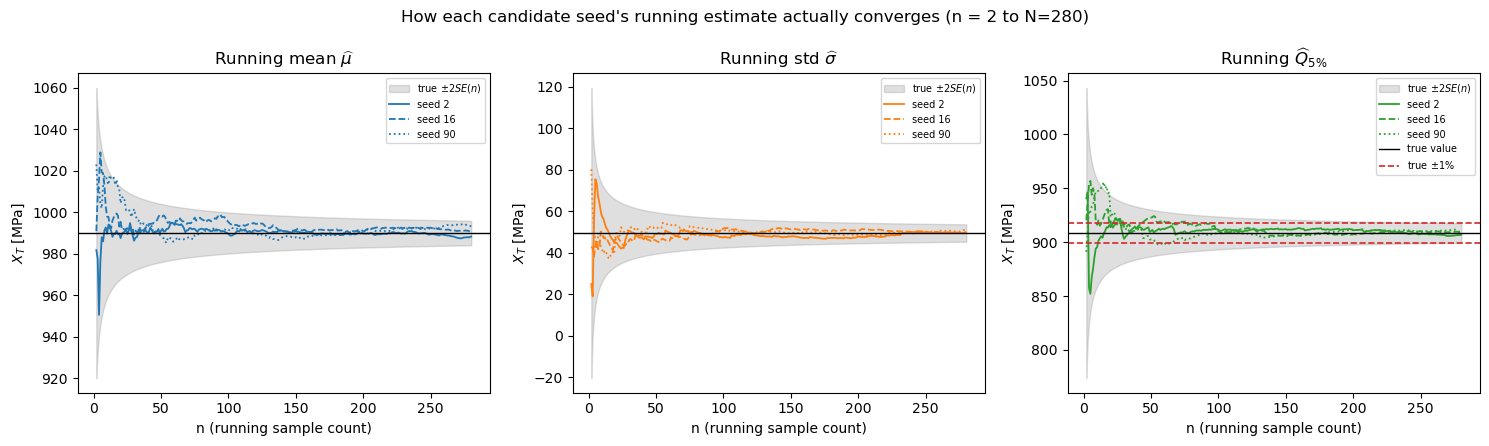

Running Q5% settling point (first n after which the +-1% band is never left again):
  seed 2: settles by n=28 (of N=280)
  seed 16: settles by n=76 (of N=280)
  seed 90: settles by n=65 (of N=280)


In [7]:
n_range = np.arange(2, N + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
se_mean_n = SIGMA / np.sqrt(n_range)
se_std_n = SIGMA / np.sqrt(2 * (n_range - 1))
se_q5_n = np.array([relse_q_p(n, Z_5) for n in n_range]) * TARGET_Q5

axes[0].fill_between(n_range, MU - 2 * se_mean_n, MU + 2 * se_mean_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")
axes[1].fill_between(n_range, SIGMA - 2 * se_std_n, SIGMA + 2 * se_std_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")
axes[2].fill_between(n_range, TARGET_Q5 - 2 * se_q5_n, TARGET_Q5 + 2 * se_q5_n, color="gray", alpha=0.25, label=r"true $\pm2SE(n)$")

# All three seeds are draws of X_T itself (the INPUT distribution), so all three lines use C0
# throughout -- distinguished from each other by linestyle instead of colour, per this
# notebook's colour convention (see Part 1).
seed_linestyles = {2: "-", 16: "--", 90: ":"}
for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    running_mean = np.cumsum(s)[n_range - 1] / n_range   # cumsum(s)[n-1] = sum of the first n draws
    running_std = np.array([s[:n].std(ddof=1) for n in n_range])
    running_q5 = running_mean + Z_5 * running_std
    ls = seed_linestyles[seed]
    axes[0].plot(n_range, running_mean, color="C0", ls=ls, lw=1.3, label=f"seed {seed}")
    axes[1].plot(n_range, running_std, color="C1", ls=ls, lw=1.3, label=f"seed {seed}")
    axes[2].plot(n_range, running_q5, color="C2", ls=ls, lw=1.3, label=f"seed {seed}")

axes[0].axhline(MU, color="k", lw=1)
axes[1].axhline(SIGMA, color="k", lw=1)
axes[2].axhline(TARGET_Q5, color="k", lw=1, label="true value")

# The actual +-1% target this notebook sizes N against, shown on the Q5% panel only.
axes[2].axhline(TARGET_Q5 * (1 - TARGET_REL), color="C3", ls="--", lw=1.2, label=f"true $\\pm${TARGET_REL:.0%}")
axes[2].axhline(TARGET_Q5 * (1 + TARGET_REL), color="C3", ls="--", lw=1.2)

for ax, title in zip(axes, ["Running mean $\\widehat\\mu$", "Running std $\\widehat\\sigma$", "Running $\\widehat{Q}_{5\\%}$"]):
    ax.set_xlabel("n (running sample count)")
    ax.set_ylabel("$X_T$ [MPa]")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle(f"How each candidate seed's running estimate actually converges (n = 2 to N={N})")
fig.tight_layout()
plt.show()

# For each seed, the smallest n after which the running Q5% estimate NEVER again strays
# outside the +-1% target band - i.e. where it settles for good, not just the first time it
# happens to pass through the band on its way to a later excursion.
print("Running Q5% settling point (first n after which the +-1% band is never left again):")
for seed in CANDIDATE_SEEDS:
    s = samples[seed]
    running_mean = np.cumsum(s)[n_range - 1] / n_range
    running_std = np.array([s[:n].std(ddof=1) for n in n_range])
    running_q5 = running_mean + Z_5 * running_std
    inside = np.abs(running_q5 - TARGET_Q5) / TARGET_Q5 <= TARGET_REL
    outside_idx = np.where(~inside)[0]
    settle_n = n_range[0] if len(outside_idx) == 0 else n_range[min(outside_idx[-1] + 1, len(n_range) - 1)]
    print(f"  seed {seed}: settles by n={settle_n} (of N={N})")

The mean and standard deviation curves of the three seeds are all within the $\pm2SE(n)$ band for essentially the entire range of $n$, while $\widehat{Q_{5\%}}$ swings outside the $\pm1\%$ target at small $n$ and only settles inside it by $n=28$ to $76$ (printed above), well before the full $N=280$ &ndash; and it visibly wanders more than either $\widehat\mu$ or $\widehat\sigma$ on their own, even though the $\pm2SE(n)$ band around it is drawn on the *same* $\pm1\%$-of-true-value scale as the target it is checked against. This is not a plotting artifact; it is the amplification effect this notebook's own derivation predicts: $\widehat{Q_{5\%}}=\widehat\mu+z_{5\%}\widehat\sigma$ inherits $\widehat\sigma$'s own noise, scaled up by $|z_{5\%}|\approx1.645$, on top of whatever noise $\widehat\mu$ already contributes &ndash; exactly the quadrature-sum relationship from Part 2's derivation, now visible as three curves converging at three visibly different rates.

We make the arbitrary choice to use **Seed 2** for the rest of this notebook.

In [8]:
# Commit to seed 2 for the campaign below
SEED = 2
x_t_campaign = samples[SEED]
assert (x_t_campaign > 0).all(), "Drew a non-physical negative X_T - see the negative-tail caveat earlier."

## Part 3 &ndash; Preparing the campaign

### Sizing the Static step's displacement budget

With $N=280$ and a committed seed (Part 2), one practical detail needs checking before
spending any Abaqus time: NB1's own baseline run used a single fixed prescribed displacement,
`TARGET_U1=3.0` mm, sized for one point ($X_T=990$ MPa) only. This campaign instead runs
$X_T$ across the whole range seed 2's 280 draws actually cover, so the step has to stay
adequate over that *whole* range, not just the nominal value.

NB1 derived the **full-failure displacement** &mdash; the displacement (measured from the
origin) at which `DAMAGEFT` reaches 1.0 and the fiber-tension stiffness is fully removed &mdash;
from the fracture energy $G_{fT}$ and the strength $X_T$ itself (linear softening, NB1's
energy-based damage-evolution theory):

$$
\delta_f = \frac{2\,G_{fT}}{X_T}.
$$

$\delta_f$ is *inversely* proportional to $X_T$: a **smaller** strength needs a **larger**
displacement to fully soften (the same fracture energy $G_{fT}$, dissipated by a lower peak
stress, needs a longer softening branch to make up the same area under the $\sigma$-$\delta$
curve). At the nominal $X_T=990$ MPa this gives $\delta_f\approx2.61$ mm, which is NB1's own
number, and the reason NB1 prescribed $U_1=3.0$ mm: enough to see the whole softening branch
play out at that one value.

This campaign samples $X_T$ as low as the smallest of the 280 draws, so **the binding case is
the smallest sampled $X_T$**, not the nominal value. The cell below checks it directly, and
sizes `TARGET_U1` from that worst case rather than from NB1's single-point number.

This notebook only ever reads off $F_{peak}$, the force at the *instant* of damage initiation, which happens far
earlier in the loading history than full failure, so in principle the step could safely stop
right after initiation without ever reaching $\delta_f$. The check below is still worth doing
because it costs nothing extra and keeps every stored run's full history complete (useful if a
later notebook wants $\delta_f$ too, or wants to plot the whole softening branch the way Part
4's cloud plot does below), but it is not, strictly, required for the one quantity this
notebook is actually built around.

In [9]:
GfT = 1290.0      # N/mm, fiber-tension fracture energy - literal source value (NB1)


def delta_f(x_t):
    """Full-failure displacement (measured from the origin, per NB1's theory) at a given
    X_T."""
    return 2.0 * GfT / x_t


# The binding case is the SMALLEST X_T actually drawn for this campaign - not the nominal
# value NB1 checked against - since delta_f grows as X_T shrinks.
x_t_min_campaign = float(x_t_campaign.min())
delta_f_nominal = delta_f(MU)
delta_f_worst = delta_f(x_t_min_campaign)
delta_f_worst_ceil = float(np.ceil(delta_f_worst))  # bare minimum: next whole mm above the worst-case need

# The bare minimum above would leave only about 1% margin - workable in principle, but
# uncomfortably tight for an analytical estimate that is itself built on NB1's own
# APPROXIMATED fracture-energy values (see NB1's material table). This campaign affords one
# full extra millimeter of margin beyond that minimum: a larger TARGET_U1 costs only a modest
# number of additional solver increments per run, at essentially no wall-clock penalty, so
# there is no reason not to buy the extra safety margin.
TARGET_U1 = delta_f_worst_ceil + 1.0

print(f"delta_f at nominal X_T={MU:.0f} MPa (NB1's own check):  {delta_f_nominal:.3f} mm")
print(f"Smallest sampled X_T (this campaign):                  {x_t_min_campaign:.2f} MPa")
print(f"delta_f at that smallest X_T (the binding case):       {delta_f_worst:.3f} mm")
print(f"Bare minimum: ceil({delta_f_worst:.3f}) = {delta_f_worst_ceil:.1f} mm "
      f"({(delta_f_worst_ceil - delta_f_worst) / delta_f_worst:.1%} margin - workable but tight)")
print(f"TARGET_U1 = {delta_f_worst_ceil:.1f} + 1.0 = {TARGET_U1:.1f} mm "
      f"(margin: {TARGET_U1 - delta_f_worst:.3f} mm, {(TARGET_U1 - delta_f_worst) / delta_f_worst:.1%} above the need)")

delta_f at nominal X_T=990 MPa (NB1's own check):  2.606 mm
Smallest sampled X_T (this campaign):                  869.15 MPa
delta_f at that smallest X_T (the binding case):       2.968 mm
Bare minimum: ceil(2.968) = 3.0 mm (1.1% margin - workable but tight)
TARGET_U1 = 3.0 + 1.0 = 4.0 mm (margin: 1.032 mm, 34.8% above the need)


As expected, the smallest sampled $X_T$ ($\approx869$ MPa) is indeed the binding case,
needing $\delta_f\approx2.97$ mm &ndash; more than NB1's nominal-point number, exactly because
$\delta_f$ grows as $X_T$ shrinks. `TARGET_U1=4.0` mm (the value the campaign in Part 4 is actually run at) gives about 1.03 mm of margin, roughly 35% above the actual
worst-case need.

The Static step's increment settings (`initialInc`, `minInc`, `maxNumInc`) aren't tied to the
absolute scale of $X_T$ the same way `TARGET_U1` is &mdash; they're expressed in normalized step
time (0 to 1, mapped onto displacement 0 to `TARGET_U1` by the default ramp amplitude) rather
than by load or displacement directly &mdash; so they carry over unchanged from NB1's own
already-working settings.

### The shared script, briefly recalled

A Monte Carlo campaign means running the same model many times, each with a different sampled
$X_T$. NB1 introduces and fully explains `scripts/build_fiber_tension.py`, the model
geometry, material, boundary conditions, Static step, and how the script's command-line
parameters are parsed (`nlgeom`, `X_T`, `U1`, `out`, all `key=value` tokens). This notebook calls the same script NB1 does, with a different `X_T` (and output path) each run:

```
python build_fiber_tension.py nlgeom=OFF X_T=<sampled value> U1=4.0 out=../runs/nb02/run_<sample index>.json
```

## Part 4 &ndash; The Monte Carlo campaign

With the sample size derived (Part 2), the displacement budget checked and the shared script
recalled (Part 3), the campaign itself is: run each of the $N=280$ sampled $X_T$ values through
Abaqus with `nlgeom=OFF`, and keep the *entire* $u_1$-$RF_1$ and damage-criterion history from
every run.

**Everything below, except one piece, is new to this notebook**: the sampling, the subprocess
launch, the resumable summary CSV, the reconstruction of every run's peak. For this reason, we
define and explain each piece in the cells below, in the order they are used:

1. **`run_one_sample`** &mdash; launches `build_fiber_tension.py` once, for one sampled $X_T$,
   and saves that one run's full recorded history to disk.
2. **`run_campaign`** &mdash; loops `run_one_sample` over all $N=280$ sampled values,
   reconstructs each run's peak force as it goes, and appends one row per sample to a summary
   CSV; resumable, so re-running this notebook later never repeats a completed sample.
3. **`load_campaign`** &mdash; reads that summary CSV back into plain numpy arrays, for Part 5
   to analyze.

The one piece that *isn't* new is peak reconstruction itself: NB1 already derived and explained
the double-linear-fit method, so that one function is simply reused from where NB1 left it, in a
small shared module, **[`scripts/peak_reconstruction.py`](../scripts/peak_reconstruction.py)**.
It provides two functions, both following exactly NB1's method: `reconstruct_peak(u1, rf1,
hsn_ft)` returns the pair `(u1_peak, f_peak)` &mdash; the displacement and force at the
reconstructed peak; `reconstruct_full_failure(u1, rf1, damage_ft)` returns the single
displacement at which the ply is fully failed. This notebook only needs the first of the two.

**Every run's output goes to `../runs/nb02/`**, a folder dedicated to this notebook's own
campaign (the same `runs/` convention NB1 uses for its own two runs): one JSON file per sample
(`run_000.json` .. `run_279.json`, the same schema `build_fiber_tension.py` already writes) plus
a summary CSV, `summary.csv`, with one row per completed sample.

### Launching one Abaqus run

The cell below defines `run_one_sample`: the function that actually launches
`build_fiber_tension.py` for one sampled $X_T$ and saves its full recorded history to disk.

In [10]:
from pathlib import Path
import sys
import time
import json
import subprocess

SCRIPTS_DIR = Path("../scripts")  # where build_fiber_tension.py itself lives, and this
                                   # subprocess's own working directory (cwd= below)


def run_one_sample(x_t, run_json, target_u1):
    """Run build_fiber_tension.py once at nlgeom=OFF for the given X_T, and save its full
    recorded force-displacement/damage history straight to run_json. build_fiber_tension.py's
    own `out=` parameter creates run_json's parent folder automatically if it doesn't exist yet
    (see the script's own docstring), so there is no separate directory setup here, and no
    intermediate file to write and copy afterward.

    run_json is given relative to THIS notebook (notebooks/); the same relative path, passed
    unchanged as `out=`, also resolves correctly from inside the subprocess (cwd=SCRIPTS_DIR),
    because notebooks/ and scripts/ are both direct siblings of runs/ under the repo root --
    not something to rely on if that folder layout ever changed, but true here (see NB1).

    If run_json already exists, the Abaqus call is skipped entirely and the saved history is
    read back instead -- this single file-existence check is what makes ONE run resumable; it
    is used both by every campaign sample below (via run_campaign) and, later in this Part, by
    the standalone nominal reference run, which has no summary-CSV row of its own to resume from.

    Returns (data, elapsed_seconds); elapsed_seconds is 0.0 for a skipped (already-run) sample.
    """
    run_json = Path(run_json)
    if run_json.exists():
        with open(run_json) as f:
            return json.load(f), 0.0

    t0 = time.perf_counter()
    result = subprocess.run(
        [sys.executable, "build_fiber_tension.py", "nlgeom=OFF", f"X_T={x_t:.6f}",
         f"U1={target_u1}", f"out={run_json.as_posix()}"],
        cwd=str(SCRIPTS_DIR),
        capture_output=True,
        text=True,
    )
    elapsed = time.perf_counter() - t0

    # result.returncode is NOT a reliable success signal on this Abaqus install (see CLAUDE.md
    # and abqpy_notes.md): abqpy's `from abaqus import *` unconditionally calls sys.exit(0) once
    # it hands the script to real Abaqus, regardless of whether that Abaqus run itself
    # succeeded. The only trustworthy signal is whether the declared output file actually
    # appeared.
    if not run_json.exists():
        raise RuntimeError(
            f"X_T={x_t:.2f} MPa did not produce results -- stdout:\n{result.stdout}\n"
            f"stderr:\n{result.stderr}"
        )

    with open(run_json) as f:
        data = json.load(f)
    return data, elapsed

### Running (and resuming) the whole campaign

`run_one_sample` runs exactly one sample. The cell below adds the loop over all $N=280$ sampled
$X_T$ values, appends one summary row per sample to `summary.csv` as it goes (so a crash or
interruption partway through loses nothing already completed), and skips whatever this campaign
has already run: because samples are always appended to `summary.csv` in order, "already run"
simply means "the first `n_done` rows of `summary.csv` already match the first `n_done` values of
this notebook's own `x_t_campaign`". This is checked explicitly before trusting it, so a changed
seed can never silently mix two different campaigns' results.

In [11]:
import csv
import numpy as np

sys.path.insert(0, "../scripts")  # so `import peak_reconstruction` below finds the module
from peak_reconstruction import reconstruct_peak

# One column per quantity a completed sample needs: the sampled input, the reconstructed peak
# (force and its displacement), the HSNFTCRT budget check, and how long the run itself took.
FIELDNAMES = ["sample_index", "x_t_mpa", "f_peak_recon_n", "u1_peak_recon_mm",
              "hsnftcrt_max", "hsnftcrt_ok", "run_seconds"]


def load_campaign(summary_csv):
    """Read a campaign's summary CSV back into plain numpy arrays, sorted by sample index. A
    campaign with no file yet (nothing run so far) reads back as empty arrays rather than
    raising, so run_campaign can call this before its own first sample has ever run."""
    summary_csv = Path(summary_csv)
    if not summary_csv.exists():
        return {"x_t": np.array([]), "f_peak_recon": np.array([]), "u1_peak_recon": np.array([]),
                "hsn_ok": np.array([], dtype=bool), "run_seconds": np.array([])}
    with open(summary_csv, newline="") as f:
        rows = list(csv.DictReader(f))
    rows.sort(key=lambda r: int(r["sample_index"]))  # rows are appended in order already, but
                                                       # sort explicitly rather than assume it
    return {
        "x_t": np.array([float(r["x_t_mpa"]) for r in rows]),
        "f_peak_recon": np.array([float(r["f_peak_recon_n"]) for r in rows]),
        "u1_peak_recon": np.array([float(r["u1_peak_recon_mm"]) for r in rows]),
        "hsn_ok": np.array([r["hsnftcrt_ok"] == "True" for r in rows]),  # csv stores everything as text
        "run_seconds": np.array([float(r["run_seconds"]) for r in rows]),
    }


def run_campaign(x_t_campaign, runs_dir, summary_csv, target_u1):
    """Run every sample in x_t_campaign, in order, appending one summary row per sample to
    summary_csv. Already-recorded samples are skipped (see markdown above)."""
    runs_dir = Path(runs_dir)
    runs_dir.mkdir(exist_ok=True, parents=True)
    summary_csv = Path(summary_csv)

    existing = load_campaign(summary_csv)
    n_done = len(existing["x_t"])
    if n_done:
        # Every previously-recorded X_T must still match this notebook's own current draw at
        # the same index, or a resumed run risks silently mixing two different campaigns.
        assert np.allclose(existing["x_t"], x_t_campaign[:n_done]), (
            f"{summary_csv} already holds a different X_T draw than this notebook's own -- "
            "delete it (and its run_*.json files) to start a fresh campaign rather than mixing two."
        )

    write_header = not summary_csv.exists()
    t_segment_start = time.perf_counter()
    n_new = 0
    with open(summary_csv, "a", newline="") as f:  # "a": append, so already-written rows are untouched
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        for i in range(n_done, len(x_t_campaign)):  # only the samples NOT already recorded
            x_t = x_t_campaign[i]
            run_json = runs_dir / f"run_{i:03d}.json"
            data, elapsed = run_one_sample(x_t, run_json, target_u1)

            u1_peak, f_peak = reconstruct_peak(data["u1"], data["rf1"], data["hsn_ft"])
            hsn_max = float(np.max(data["hsn_ft"]))
            hsn_ok = hsn_max >= 0.99  # confirms the displacement budget reached damage initiation
            writer.writerow({
                "sample_index": i, "x_t_mpa": x_t,
                "f_peak_recon_n": f_peak, "u1_peak_recon_mm": u1_peak,
                "hsnftcrt_max": hsn_max, "hsnftcrt_ok": hsn_ok, "run_seconds": elapsed,
            })
            n_new += 1

            if not hsn_ok:
                print(f"[{i}] WARNING: HSNFTCRT_max={hsn_max:.3f} did not reach ~1.0 - investigate this sample.")
            if i % 40 == 0 or i == len(x_t_campaign) - 1:  # a progress line every 40 samples, plus the very last one
                print(f"[{i + 1}/{len(x_t_campaign)}] X_T={x_t:7.2f} MPa -> "
                      f"F_peak_recon={f_peak:8.2f} N  ({elapsed:.1f}s)")

    if n_new:
        print(f"\nRan {n_new} new sample(s) this session in {time.perf_counter() - t_segment_start:.0f}s.")
    else:
        print(f"\nAll {len(x_t_campaign)} samples already completed - read back from disk, no new Abaqus jobs.")

With the campaign machinery now defined, the cell below actually runs it: $N=280$ Abaqus jobs,
one per sampled $X_T$, saved under `../runs/nb02/`. If this notebook has been run before, every
sample is already on disk and `run_campaign` reads them straight back instead of relaunching
Abaqus (watch for the "already completed" message in the printed output below). If not,
budget on the order of ninety minutes for the first run: the progress line printed every 40
samples is the way to check it is actually moving.

In [12]:
RUNS_DIR = Path("../runs/nb02")         # this campaign's own output folder (see Part 4's intro)
SUMMARY_CSV = RUNS_DIR / "summary.csv"  # one row per completed sample, appended as the campaign runs

run_campaign(x_t_campaign, RUNS_DIR, SUMMARY_CSV, TARGET_U1)


All 280 samples already completed - read back from disk, no new Abaqus jobs.


With the campaign either just completed or read back from disk, the cell below reports its
total cost directly from `summary.csv`'s own `run_seconds` column, the sum of every
individual run's own solve time.

In [13]:
run_seconds = load_campaign(SUMMARY_CSV)["run_seconds"]  # one value per completed sample
print(f"--- nlgeom=OFF campaign cost ({len(run_seconds)} completed runs) ---")
print(f"Total wall-clock time (sum of every run's own solve time): {run_seconds.sum():8.0f} s "
      f"({run_seconds.sum() / 3600:.2f} h)")
# min/max/std are printed alongside the mean so an unusually slow (or fast) individual run
# would stand out here, rather than being hidden inside a single averaged number.
print(f"Per-run solve time:  mean={run_seconds.mean():.1f}s, std={run_seconds.std(ddof=1):.1f}s, "
      f"min={run_seconds.min():.1f}s, max={run_seconds.max():.1f}s")

--- nlgeom=OFF campaign cost (280 completed runs) ---
Total wall-clock time (sum of every run's own solve time):     5490 s (1.52 h)
Per-run solve time:  mean=19.6s, std=1.4s, min=18.9s, max=34.3s


Most of that time is Abaqus itself (license checkout, kernel startup, and the solve), with only
a small Python-side overhead for subprocess bookkeeping and file I/O not reflected in
`run_seconds`.

To see this campaign's results as more than a table of numbers, the cell below runs one more,
dedicated Abaqus job at exactly $X_T=\mu$ (the "nominal" run, reusing `run_one_sample` directly
&ndash; it has no summary-CSV row of its own, so its own resumability is exactly the file-existence
check `run_one_sample` already makes) and plots every sampled run's full force-displacement curve
underneath it, so the whole Monte Carlo cloud is visible at once.

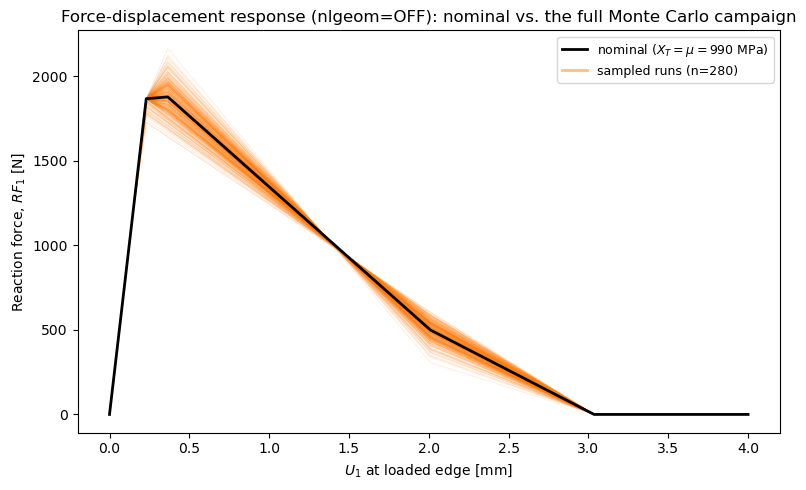

In [14]:
NOMINAL_JSON = RUNS_DIR / "run_nominal.json"
nominal_data, _ = run_one_sample(MU, NOMINAL_JSON, TARGET_U1)  # one extra run at X_T=mu exactly, purely for this plot

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(N):  # every sampled run's own force-displacement curve, drawn very faintly
    with open(RUNS_DIR / f"run_{i:03d}.json") as f:
        run_data = json.load(f)
    ax.plot(run_data["u1"], run_data["rf1"], color="C1", lw=0.6, alpha=0.15)  # C1: F_peak is the output distribution

ax.plot(nominal_data["u1"], nominal_data["rf1"], color="k", lw=2,
        label=f"nominal ($X_T=\\mu={MU:.0f}$ MPa)")
ax.plot([], [], color="C1", lw=2, alpha=0.5, label=f"sampled runs (n={N})")  # a dummy (empty) line, purely to add a legend entry for the faint cloud above
ax.set_xlabel("$U_1$ at loaded edge [mm]")
ax.set_ylabel("Reaction force, $RF_1$ [N]")
ax.set_title("Force-displacement response (nlgeom=OFF): nominal vs. the full Monte Carlo campaign")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The shaded band of sampled curves fans out around the black nominal curve, wider the further
past the peak each run gets. Two things about $X_T$'s scatter explain the shape of this band
completely. Before the peak, every curve rides the *same* elastic line (all runs share $E_1$ and
geometry, so $F=(E_1A/L)u_1$ is identical regardless of $X_T$); the band only opens up right at
the peak itself, where each curve's own $F_{peak}=A\cdot X_T$ places it. Past the peak, the band
keeps widening because the *softening* branch's length is set by
$\delta_f=2G_{fT}/X_T$ (Part 3): a weaker ply (smaller $X_T$) needs a *longer* displacement to
dissipate the same fracture energy $G_{fT}$, so the lowest-strength runs trail furthest to the
right, while the highest-strength runs both peak higher and finish softening sooner. Part 5 turns
this qualitative picture into the actual verified statistics.

## Part 5 &ndash; Results

Everything below is computed from the campaign's own `../runs/nb02/summary.csv`, loaded fresh so
this section reports correctly whether the campaign above just ran in this kernel session or was
read back from disk.

In [15]:
off_data = load_campaign(SUMMARY_CSV)  # every completed sample, as plain numpy arrays
n_run = len(off_data["x_t"])
print(f"Loaded {n_run} completed runs (planned N={N}).")
if n_run < N:
    print(f"WARNING: only {n_run} of the planned {N} runs completed - the analysis below reflects those {n_run} points only.")
if not off_data["hsn_ok"].all():
    # hsn_ok is False for any run whose HSNFTCRT never reached ~1.0 -- i.e. TARGET_U1 (Part 3)
    # turned out too short to reach damage initiation for that particular X_T. Shouldn't happen
    # given how TARGET_U1 was sized, so this is a genuine red flag if it ever fires.
    n_bad = int((~off_data["hsn_ok"]).sum())
    print(f"WARNING: {n_bad} run(s) did not reach HSNFTCRT~=1.0 - investigate before trusting this data.")

# A run's peak can fail to reconstruct if its recorded history has too few increments either
# side of initiation for reconstruct_peak's two-point line fits (see peak_reconstruction.py) --
# rare, but every later cell in this notebook needs f_recon to contain no NaNs, so it is
# filtered out here, once, rather than re-checked in every downstream cell.
recon_valid = ~np.isnan(off_data["f_peak_recon"])
n_recon_failed = int((~recon_valid).sum())
if n_recon_failed:
    print(f"WARNING: {n_recon_failed} run(s) could not be reconstructed (too few recorded increments "
          f"around initiation) - excluded from every statistic below.")

x_t = off_data["x_t"][recon_valid]
f_recon = off_data["f_peak_recon"][recon_valid]   # THE quantity every later cell in this notebook uses

Loaded 280 completed runs (planned N=280).


No warnings above means the campaign loaded all $N$ planned runs, every run reached
`HSNFTCRT`$\approx1.0$ (the displacement budget from Part 3 held for the whole sampled range),
and every run's peak was successfully reconstructed. NB1 already established, for a single run,
that this *reconstructed* peak is the trustworthy one. The raw maximum of the recorded
`RF1` array undershoots the true peak because the solver's automatic increment spacing has no way
to know in advance where the sharp peak sits. That is settled; this notebook uses `f_peak_recon`
exclusively from here on, and Part 5 goes straight to characterizing its distribution.

### Step 1 &ndash; the simulated distribution against the analytical prediction

The first question is whether the campaign's output is trustworthy at all, before any percentile
is estimated from it: does the reconstructed peak force, aggregated over all $N=280$ runs, match
the analytical $\mathcal N(A\mu, A\sigma)$ prediction from Part 1? The cell below computes the
empirical mean and standard deviation, plots the resulting histogram against the analytical PDF,
and adds a second, more precise check: it also computes $A\cdot X_T$ directly from this
campaign's own 280 sampled $X_T$ values; in other words, what a perfect, noiseless simulator (no Abaqus
involved at all) would have produced for this *exact same draw*. Comparing that number to the
population value isolates ordinary Monte Carlo sampling noise (this one particular draw is never
going to match the population exactly, and Part 2 already predicts by how much); comparing the
actual simulated result to it isolates whatever additional error the simulation and
reconstruction themselves introduce.

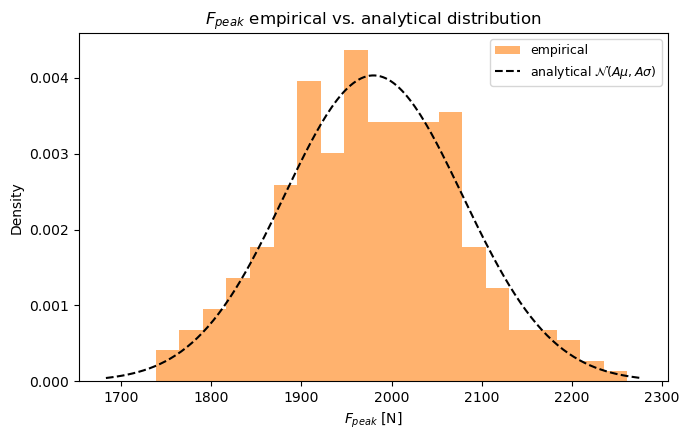

quantity          population  realized A*X_T   simulated
--------------------------------------------------------
mean [N]             1980.00         1976.51     1976.45
std [N]                99.00           98.91       98.91

Sampling error (realized A*X_T vs. population):   mean 0.18%, std 0.09%
Simulation error (simulated vs. realized A*X_T):  mean 0.00%, std 0.00%


In [16]:
mean_recon, std_recon = float(f_recon.mean()), float(f_recon.std(ddof=1))

# What a perfect, noiseless simulator would have produced for this SAME 280-sample draw of
# X_T -- no Abaqus, no reconstruction, just the exact small-strain formula from Part 1. Any gap
# between this and the simulated result below is genuinely due to Abaqus/reconstruction; any
# gap between THIS and the population value is pure Monte Carlo sampling noise.
ax_realized = A * x_t
mean_ax, std_ax = float(ax_realized.mean()), float(ax_realized.std(ddof=1))

fig, ax = plt.subplots(figsize=(7, 4.5))
n_bins = min(20, max(3, len(f_recon) // 5))  # rule of thumb: about 1 bin per 5 samples, floored at 3 bins and capped at 20, so N=280 is neither over- nor under-resolved
pad = 3 * analytical_std  # how far past the analytical mean the plotted x-range extends on either side
x_grid_f = np.linspace(analytical_mean - pad, analytical_mean + pad, 200)

ax.hist(f_recon, bins=n_bins, density=True, color="C1", alpha=0.6, label="empirical")  # C1: F_peak is the output distribution
ax.plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.5,
        label=r"analytical $\mathcal{N}(A\mu, A\sigma)$")
ax.set_xlabel("$F_{peak}$ [N]"); ax.set_ylabel("Density")
ax.set_title("$F_{peak}$ empirical vs. analytical distribution")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"{'quantity':16s}{'population':>12s}{'realized A*X_T':>16s}{'simulated':>12s}")
print("-" * 56)
print(f"{'mean [N]':16s}{analytical_mean:12.2f}{mean_ax:16.2f}{mean_recon:12.2f}")
print(f"{'std [N]':16s}{analytical_std:12.2f}{std_ax:16.2f}{std_recon:12.2f}")
print()
print(f"Sampling error (realized A*X_T vs. population):   mean {abs(mean_ax - analytical_mean) / analytical_mean:.2%}, "
      f"std {abs(std_ax - analytical_std) / analytical_std:.2%}")
print(f"Simulation error (simulated vs. realized A*X_T):  mean {abs(mean_recon - mean_ax) / mean_ax:.2%}, "
      f"std {abs(std_recon - std_ax) / std_ax:.2%}")

**All of the gap to the population value is ordinary sampling noise, not simulation error.** The realized draw's own $A\cdot X_T$ statistics (no Abaqus involved at all) sit 0.18% low on the mean and 0.09% low on the std relative to the population. The *actual simulated* result lands on top of that realized-draw number to within 0.00% on both.
NB1 already established, for a single run, that the reconstructed peak reproduces the exact small-strain prediction; this confirms it holds at population scale too. Whatever remains between this campaign's answer and the true population value is *statistical*: this one particular 280-sample draw simply happens to sit slightly off-population, exactly the kind of scatter Part 2's standard-error theory predicts and sizes $N$ against, not a numerical artifact of the simulation.

### Step 2 &ndash; a histogram hides as much as it shows

A histogram has two choices baked into it that are entirely arbitrary: **where the bin edges
sit**, and **how wide the bins are**. Small changes to either can make the very same underlying
data look meaningfully different: more or less symmetric, one mode or two, a heavier or
lighter tail, without a single sample value having changed. The cell below draws the same
280 force peaks three different ways, each against the same analytical PDF, to make that
concrete.

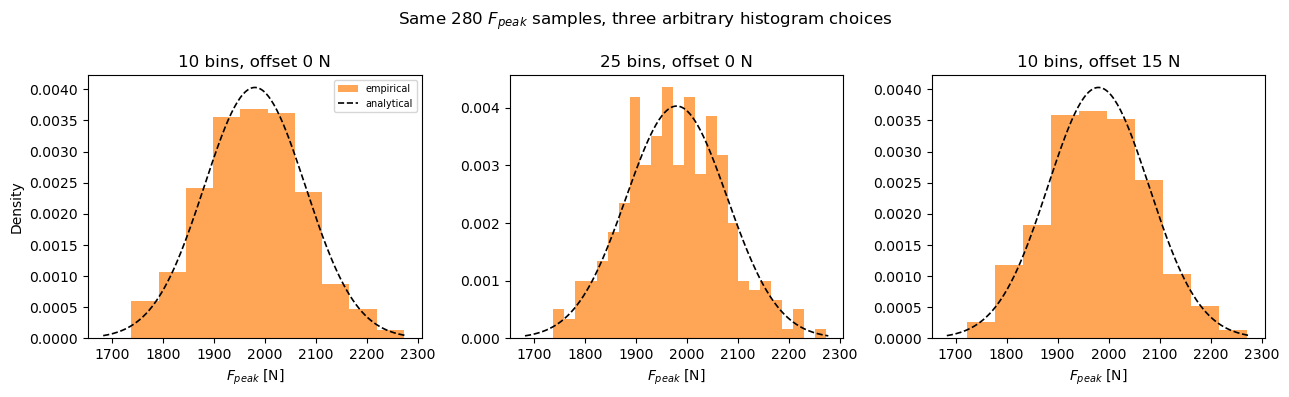

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
bin_choices = [(10, 0.0), (25, 0.0), (10, 15.0)]  # (number of bins, bin-edge offset in N) -- three arbitrary but reasonable choices
for ax, (n_bins_i, offset) in zip(axes, bin_choices):
    edges = np.linspace(f_recon.min() - offset, f_recon.max() + 10, n_bins_i + 1)  # shifting the left edge by `offset` moves where the bins fall, with no change to the underlying data
    ax.hist(f_recon, bins=edges, density=True, color="C1", alpha=0.7, label="empirical")  # C1: output distribution
    ax.plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.2,
            label="analytical")
    ax.set_title(f"{n_bins_i} bins, offset {offset:.0f} N")
    ax.set_xlabel("$F_{peak}$ [N]")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=7)
fig.suptitle("Same 280 $F_{peak}$ samples, three arbitrary histogram choices")
fig.tight_layout()
plt.show()

The overall bell-looking shape survives every choice, and stays relatively close to the analytical curve in all three panels. However, fine details such as how tall each bin is and where a local bump or dip appears, are not consistent across the different histogram choices. None of that fine detail is real; it is an artifact of where the analyst happened to draw the bin edges. A method that builds in fewer arbitrary choices would be preferable, which is exactly what kernel density estimation provides.

### Step 3 &ndash; kernel density estimation (KDE)

**The idea.** Instead of sorting samples into a small number of bins, place a small, smooth
"bump" &mdash; a **kernel** &mdash; centered on *every single sample point*, and add all $N$
bumps together. Averaging $N$ Gaussian kernels of width (**bandwidth**) $h$ gives the density
estimate

$$
\hat f(x) = \frac{1}{Nh}\sum_{i=1}^N \phi\!\left(\frac{x - x_i}{h}\right), \qquad
\phi(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2},
$$

where $x_1,\dots,x_N$ are the $N=280$ sampled peak forces themselves; $\phi$ is the *standard* Normal PDF (mean 0, std 1), the shape of one
kernel, centered at zero; the $(x-x_i)/h$ argument rescales the distance from each sample so that
$\phi$'s own built-in width of 1 becomes a bump of width $h$ centered on $x_i$; and
$\hat f(x)$, the estimate, is the *average* of all $N$ of these shifted, rescaled bumps
evaluated at $x$. Each kernel individually has area 1 under it (it is itself a genuine PDF), so
the sum of $N$ of them has area $N$, and dividing by $N$ is exactly what brings the total area
of $\hat f$ back down to 1. This idea is not new to this notebook: [Rosenblatt (1956)](https://doi.org/10.1214/aoms/1177728190) and
[Parzen (1962)](https://doi.org/10.1214/aoms/1177704472) are the two founding papers, and the
result is sometimes called a *Parzen&ndash;Rosenblatt window* for that reason.

Unlike a histogram, KDE has no bin edges to place arbitrarily; what takes their place is the single number $h$. In the next cell we define the function `kde_pdf` to compute $\hat f(x)$ for any $x$ given a set of samples and a bandwidth $h$.

In [18]:
def kde_pdf(x_eval, samples, h):
    """Gaussian KDE evaluated at x_eval: put a Gaussian "bump" of width h on top of every
    sample point and average them (see the formula above). Smooth everywhere, unlike a
    histogram."""
    x_eval = np.atleast_1d(np.asarray(x_eval, dtype=float))
    samples = np.asarray(samples, dtype=float)
    z = (x_eval[:, None] - samples[None, :]) / h  # every (evaluation point, sample) pairwise distance, rescaled by h
    return np.exp(-0.5 * z ** 2).sum(axis=1) / (len(samples) * h * np.sqrt(2.0 * np.pi))  # sum of kernels, normalized by N*h

**What $h$ actually does.** The cell below draws the same 280 samples through `kde_pdf` at three deliberately different bandwidths &mdash; one far too small, one in a sensible range, one far too large &mdash; to make the trade-off concrete before any criterion is introduced to resolve it.

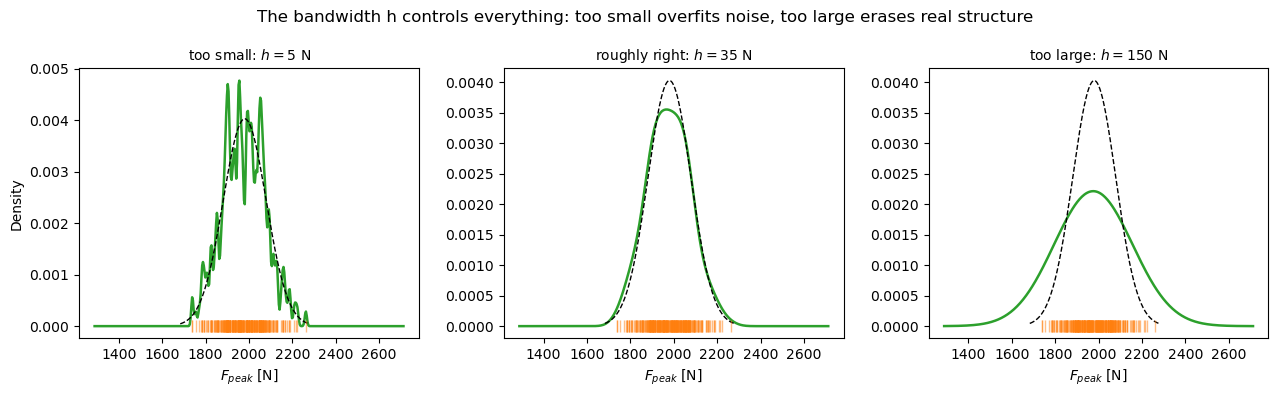

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
h_examples = [5.0, 35.0, 150.0]  # N -- deliberately too small, roughly right, and too large for this sample
titles = ["too small: $h=5$ N", "roughly right: $h=35$ N", "too large: $h=150$ N"]
x_kde_demo = np.linspace(f_recon.min() - 3 * max(h_examples), f_recon.max() + 3 * max(h_examples), 400)
for ax, h_demo, title in zip(axes, h_examples, titles):
    ax.plot(x_kde_demo, kde_pdf(x_kde_demo, f_recon, h_demo), color="C2", lw=1.8)  # C2: KDE-derived
    ax.plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.0)
    ax.plot(f_recon, np.zeros_like(f_recon), "|", color="C1", ms=8, alpha=0.5)  # tick marks: where each of the 280 samples actually sits
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$F_{peak}$ [N]")
axes[0].set_ylabel("Density")
fig.suptitle("The bandwidth h controls everything: too small overfits noise, too large erases real structure")
fig.tight_layout()
plt.show()

At $h=5$ N the estimate is a forest of narrow spikes, roughly one per sample. In other words, it is not
describing $F_{peak}$'s distribution, it is just marking where these particular 280 numbers
happened to fall (the tick marks along the bottom are those same 280 samples). At $h=150$ N the
estimate has been smoothed into a single wide, flat mound that has lost the analytical curve's
actual width and height. The middle panel, at a bandwidth close to what the rest of this Step
lands on, tracks the analytical curve closely without visibly chasing individual points.
Choosing $h$ well is the entire content of KDE: too small and the density describes the noise in
this one sample rather than the population it came from; too large and it describes almost
nothing at all. What is needed is a principled way to pick a good $h$ without simply eyeballing
it, which is exactly what the rest of this Step builds.

**Choosing $h$ without eyeballing it.** [Catalanotti (2022)](https://doi.org/10.1016/j.compositesa.2022.107238)
selects the KDE bandwidth "through optimisation, via grid search cross-validation, of the
bandwidth of the kernel", avoiding "making up" a distribution by letting the data pick its own
smoothing. Unpacked one phrase at a time:

- **Cross-validation** means holding part of the data back, fitting on the rest, and scoring
  how well that fit predicts the part held back. This measures whether the fit *generalizes*
  &mdash; will it work on data it hasn't seen &mdash; rather than how well it merely matches
  data it has already been given (which a small enough $h$ can always do perfectly, for the
  wrong reason, as the leftmost panel above just showed).
- **Grid search** means trying a range of candidate $h$ values on a fixed list and keeping
  whichever one scores best. With only one number to choose, this is simple and cheap enough to
  be the obvious method here.
- **"Letting the data pick its own smoothing"** is what happens once $h$ is chosen this way, by
  the score above, instead of by a formula that assumes a distributional shape, or by looking at
  a plot and picking what looks right.

**Leave-one-out cross-validation** is this idea taken to its smallest possible version: instead
of holding back a whole chunk of the data, hold back **one point at a time**, and let every
point take a turn being the one held out. For a candidate $h$, build the density from every
sample *except* $x_i$, and evaluate it at the left-out $x_i$ itself:

$$
\hat f_{-i}(x_i) = \frac{1}{(N-1)h}\sum_{j\neq i} \phi\!\left(\frac{x_i - x_j}{h}\right).
$$

This is exactly the KDE formula above, with $x_i$ itself removed from the sum and the
normalization changed from $N$ to $N-1$ points. In other words, leaving $x_i$ out removes that shortcut and asks the honest question instead: *if
this one point had never been observed, would the density built from every other point have predicted it well?*

**Summing the logs.** $\hat f_{-i}(x_i)$ is a probability density: the height the left-out model
assigns at $x_i$'s own location. Multiplying these heights together across every point,
$\prod_{i=1}^N \hat f_{-i}(x_i)$, is the *likelihood* of the whole sample under this
leave-one-out scheme, that is to say how probable the data as a whole looks under it. Maximizing that
product over $h$ would work in principle, but 280 densities of order $10^{-2}$ multiplied
together underflow to exactly zero in ordinary floating-point arithmetic; the logarithm turns
the product into a sum, $\sum_{i=1}^N \log\hat f_{-i}(x_i)$, which is numerically well-behaved and, because $\log$ is a strictly increasing function, has its
maximum at exactly the same $h$ as the product would. This sum is the **leave-one-out
log-likelihood** of $h$; the $h$ that maximizes it is the one whose density predicts each
held-out point best, on average, using only the *other* points.

The cell below defines the functions to run this search and then executes the search and plots the leave-one-out log-likelihood against every
candidate $h$ on the grid.

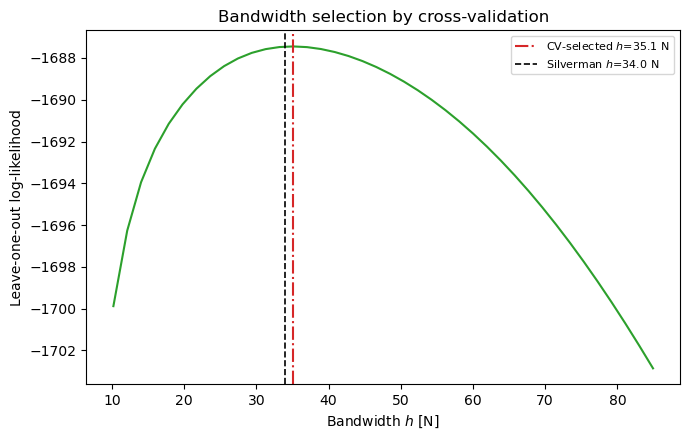

Cross-validated bandwidth: h = 35.10 N  (Silverman rule: 33.97 N, ratio 1.033)


In [20]:
def silverman_bandwidth(x):
    """Silverman's rule-of-thumb bandwidth, h = 1.06 * s * n**(-1/5) (Silverman, 1986) -- a
    closed-form starting point for the grid search below, not the answer itself. It minimizes
    the *asymptotic mean integrated squared error* -- the expected squared gap between the
    estimated and true density, integrated over all x -- but only under the assumption that the
    true density is Normal. The n**(-1/5) factor is why it shrinks only slowly as more data
    arrives: more samples support finer detail, but only a little at a time."""
    x = np.asarray(x, dtype=float)
    return float(1.06 * x.std(ddof=1) * len(x) ** (-0.2))


def kde_loo_log_likelihood(x, h):
    """Leave-one-out log-likelihood of bandwidth h for sample x (see markdown above): for each
    point, build the density from every OTHER point and evaluate it there, then sum the logs."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    z = (x[:, None] - x[None, :]) / h                 # every pairwise standardised distance x_i - x_j
    k = np.exp(-0.5 * z ** 2)                          # phi(z) for every pair (missing its 1/(h*sqrt(2*pi)) normalization for now)
    np.fill_diagonal(k, 0.0)                           # this is the "leave one out": drop each point's own kernel from its own sum
    dens = k.sum(axis=1) / ((n - 1) * h * np.sqrt(2.0 * np.pi))  # normalize each row -> f_{-i}(x_i), one value per sample
    return float(np.log(np.maximum(dens, 1e-300)).sum())  # sum of logs; the tiny floor avoids log(0) if a density ever rounds to exactly zero


def kde_loo_bandwidth(x, n_grid=40, lo_factor=0.3, hi_factor=2.5):
    """Choose the KDE bandwidth by grid search on the leave-one-out log-likelihood. The grid
    spans lo_factor to hi_factor times Silverman's rule, which brackets the optimum comfortably
    for the unimodal samples this repository produces."""
    x = np.asarray(x, dtype=float)
    h_grid = silverman_bandwidth(x) * np.linspace(lo_factor, hi_factor, n_grid)  # candidate h's, centered on Silverman's rule
    ll = np.array([kde_loo_log_likelihood(x, h) for h in h_grid])  # the score for every candidate
    h_best = float(h_grid[int(np.argmax(ll))])  # the grid search itself: simply keep the best-scoring candidate
    return h_best, h_grid, ll

# Perform the grid search for the best bandwidth, and also compute Silverman's rule-of-thumb
h_best, h_grid, loo_ll = kde_loo_bandwidth(f_recon)
h_silverman = silverman_bandwidth(f_recon)

# Plot the leave-one-out log-likelihood vs. bandwidth, with vertical lines for the CV-selected and Silverman bandwidths
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_grid, loo_ll, color="C2", lw=1.5)  # C2: KDE-derived
ax.axvline(h_best, color="C3", ls="-.", lw=1.5, label=f"CV-selected $h$={h_best:.1f} N")
ax.axvline(h_silverman, color="k", ls="--", lw=1.2, label=f"Silverman $h$={h_silverman:.1f} N")
ax.set_xlabel("Bandwidth $h$ [N]")
ax.set_ylabel("Leave-one-out log-likelihood")
ax.set_title("Bandwidth selection by cross-validation")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Print the selected bandwidths and their ratio, so the user can see how far Silverman's rule is from the CV optimum
print(f"Cross-validated bandwidth: h = {h_best:.2f} N  (Silverman rule: {h_silverman:.2f} N, "
      f"ratio {h_best / h_silverman:.3f})")

The leave-one-out log-likelihood rises smoothly to a single peak and falls off on both sides:
too small an $h$ overfits individual points (falling score on the left, matching the spiky left
panel of the earlier figure), too large an $h$ oversmooths genuine structure (falling score on
the right, matching that figure's flat right panel), and the peak in between is the
cross-validated choice, $h=35.10$ N. It lands close to Silverman's rule-of-thumb value, $h=33.97$
N (ratio $1.033$). This closeness is itself informative: Silverman's rule is optimal
only when the underlying density is genuinely Normal, and this notebook's output *is* provably
Normal (Part 1). The cross-validated search does not know that in advance &mdash; it only sees
280 numbers &mdash; so its landing almost exactly on Silverman's own value is a second,
independent confirmation that the campaign's output really does behave the way the closed form
predicts.

With $h$ chosen, the cell below overlays the resulting KDE on top of a histogram of the same
280 samples and the analytical PDF &mdash; the picture Step 2 argued a histogram alone cannot
give reliably.

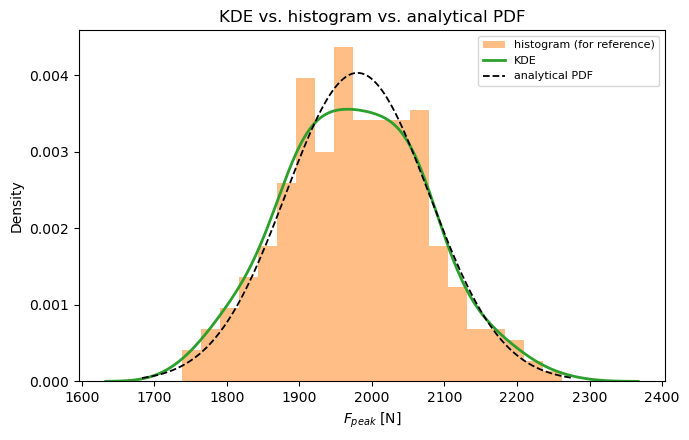

In [21]:
x_kde = np.linspace(f_recon.min() - 3 * h_best, f_recon.max() + 3 * h_best, 400)
pdf_kde = kde_pdf(x_kde, f_recon, h_best)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(f_recon, bins=n_bins, density=True, color="C1", alpha=0.5, label="histogram (for reference)")  # C1: output, empirical
ax.plot(x_kde, pdf_kde, color="C2", lw=2, label="KDE")  # C2: KDE-derived
ax.plot(x_grid_f, gaussian_pdf(x_grid_f, analytical_mean, analytical_std), "k--", lw=1.3,
        label="analytical PDF")
ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("Density")
ax.set_title("KDE vs. histogram vs. analytical PDF")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The KDE curve is a single smooth line with no bin edges anywhere, and it tracks the analytical
PDF visibly more closely than the reference histogram does. This is the better picture of
$F_{peak}$'s distribution the effect-of-$h$ figure and Step 2 were both building toward.

### Step 4 &ndash; reading $Q_{5\%}$ three ways

With the distribution now visualized two ways (histogram and KDE), the next question is the one
this whole notebook has been building toward: what is $F_{peak}$'s 5th percentile, and how much
does the answer depend on *how* it is estimated? Three estimators are compared below.

**1. The plug-in formula.** $N=280$ was sized in Part 2 for exactly this estimator,
$\widehat{Q_{5\%}}=\widehat\mu+z_{5\%}\widehat\sigma$, the exact percentile formula for a
Normal distribution, with the sample mean and standard deviation substituted for the unknown true
parameters. For `nlgeom=OFF` specifically, using this formula is not an assumption at all:
$F_{peak}=A\cdot X_T$ is an *exactly* linear map of a Normal input, so $F_{peak}$ is *provably*
Normal (Part 1), and the plug-in estimator is the maximum-likelihood estimator for exactly this
situation.

In [22]:
q5_plugin = mean_recon + Z_P["5%"] * std_recon
analytical_q5 = f_peak_percentiles["5%"]  # from Part 1

print(f"Plug-in Q5%:  {q5_plugin:.2f} N")
print(f"Analytical:   {analytical_q5:.2f} N")
print(f"Difference:   {q5_plugin - analytical_q5:+.2f} N  ({(q5_plugin - analytical_q5) / analytical_q5:+.2%})")

Plug-in Q5%:  1813.75 N
Analytical:   1817.16 N
Difference:   -3.41 N  (-0.19%)


**2. The order statistic.** The plug-in result above only means something because this notebook
*engineered* a situation where the output distribution's shape is known in advance. In
essentially every other progressive-damage UQ problem &mdash; the moment there is more than one
uncertain input, or any geometric or material nonlinearity &mdash; there is no such guarantee, and assuming Normality regardless would be exactly
the "making up" of a distributional form that a rigorous UQ study has to avoid
([Catalanotti, 2022](https://doi.org/10.1016/j.compositesa.2022.107238)).

So: pretend, for this second estimator, that we do not know in advance what the shape of $F_{peak}$'s distribution is. The **distribution-free** way to read a percentile off a finite sample is the **order statistic**: sort the $N$ simulated values, and read $Q_{5\%}$ straight off the empirical cumulative distribution function (CDF), the staircase that rises by $1/N$ at every sample point. No parameters are fit, no functional form is assumed; the percentile is simply *the value that has (approximately) 5% of the sample at or below it*.

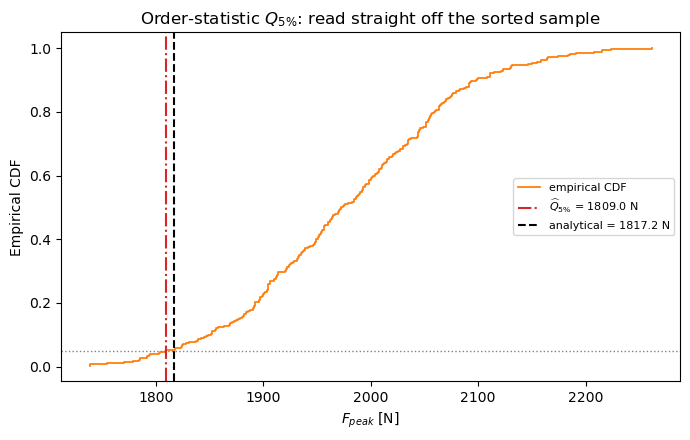

Order statistic Q5%: 1809.03 N  (-0.45% vs. analytical)


In [23]:
f_sorted = np.sort(f_recon)
ecdf = np.arange(1, len(f_sorted) + 1) / len(f_sorted)  # the i-th sorted sample sits at height i/N on the staircase

# numpy's default ("linear") interpolation between the two order statistics bracketing the 5%
# level is one convention among a few in the literature, but at N=280 they differ from each
# other by far less than the estimator's own sampling noise, so the choice is simply left at
# numpy's default here rather than compared.
q5_order_stat = float(np.percentile(f_recon, 5))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.step(f_sorted, ecdf, where="post", color="C1", lw=1.3, label="empirical CDF")
ax.axhline(0.05, color="gray", ls=":", lw=1)
ax.axvline(q5_order_stat, color="C3", ls="-.", lw=1.5, label=f"$\\widehat{{Q}}_{{5\\%}}$ = {q5_order_stat:.1f} N")
ax.axvline(analytical_q5, color="k", ls="--", lw=1.5, label=f"analytical = {analytical_q5:.1f} N")
ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("Empirical CDF")
ax.set_title("Order-statistic $Q_{5\\%}$: read straight off the sorted sample")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Order statistic Q5%: {q5_order_stat:.2f} N  ({(q5_order_stat - analytical_q5) / analytical_q5:+.2%} vs. analytical)")

Every one of the 280 sorted samples contributes one step of height
$1/280\approx0.0036$; the staircase is the sample's own empirical CDF, and it climbs toward 1 as
$F_{peak}$ increases, tracking the true (unknown, in general) CDF more and more closely as $N$
grows. $\widehat{Q_{5\%}}$ is simply *where the staircase crosses the horizontal line at 0.05*
(the dotted gray line), interpolated between the two bracketing sample points. Nothing
about the shape of the underlying distribution enters this reading at all. That is also this
estimator's weakness: only the handful of sample points that happen to sit in the immediate
neighborhood of that crossing carry any information about $Q_{5\%}$; the other roughly 270 points,
which the plug-in estimator above puts to full use in fitting $\hat\mu$ and $\hat\sigma$,
contribute nothing directly here.

**3. Kernel density estimation.** Because the KDE built in Step 3 is a sum of Gaussian kernels,
its cumulative distribution function is available in closed form too. Integrating a sum of
Gaussians term by term simply replaces each one by its own CDF:

$$
\hat F(x) = \frac{1}{N}\sum_{i=1}^N \Phi\!\left(\frac{x - x_i}{h}\right).
$$

$\hat F$ is continuous and strictly increasing, so the value of $x$ at which $\hat F(x)=0.05$ can
be found by ordinary bisection &ndash; no numerical integration needed.

In [24]:
def kde_cdf(x_eval, samples, h):
    """CDF of the Gaussian KDE above, in closed form (see markdown above): integrating a sum of
    Gaussian kernels term by term replaces each one by its own CDF."""
    x_eval = np.atleast_1d(np.asarray(x_eval, dtype=float))
    samples = np.asarray(samples, dtype=float)
    return norm.cdf((x_eval[:, None] - samples[None, :]) / h).mean(axis=1)


def kde_percentile(samples, h, p=0.05, tol=0.01):
    """The p-th percentile of the KDE, found by bisecting its closed-form CDF.

    The bisection bracket starts BRACKET_SIGMAS bandwidths outside the sample range on each
    side. A Gaussian kernel's tail is already below 1e-9 of its peak six standard deviations
    out, so starting the bracket that far beyond the data guarantees F_hat is essentially 0 at
    the low end and essentially 1 at the high end -- i.e. that the true root really does lie
    inside the starting bracket, for any percentile this notebook would ever ask for.

    The loop halves the bracket every iteration and stops once its width is below `tol`
    (newtons) -- narrow enough that the result is exact to well under a tenth of a percent of
    F_peak's own scale, several orders tighter than anything else this notebook estimates to.
    """
    samples = np.asarray(samples, dtype=float)
    BRACKET_SIGMAS = 6.0  # see docstring: far enough that the Gaussian tail there is negligible
    lo, hi = samples.min() - BRACKET_SIGMAS * h, samples.max() + BRACKET_SIGMAS * h
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if float(kde_cdf(mid, samples, h)[0]) < p:
            lo = mid  # F_hat(mid) is still below the target level -> the root is above mid
        else:
            hi = mid  # F_hat(mid) has already reached the target level -> the root is at or below mid
    return float(0.5 * (lo + hi))

**Visualizing what the bisection solves.** The cell below plots $\hat F(x)$ itself, alongside
the empirical CDF staircase from the order-statistic figure above, and marks where each crosses
the 0.05 level. This is worth seeing before Step 5 quantifies it: the KDE's smooth curve crosses
0.05 slightly to the *left* of the staircase, which is exactly the shift a lower-tail percentile
picks up from KDE's smoothing.

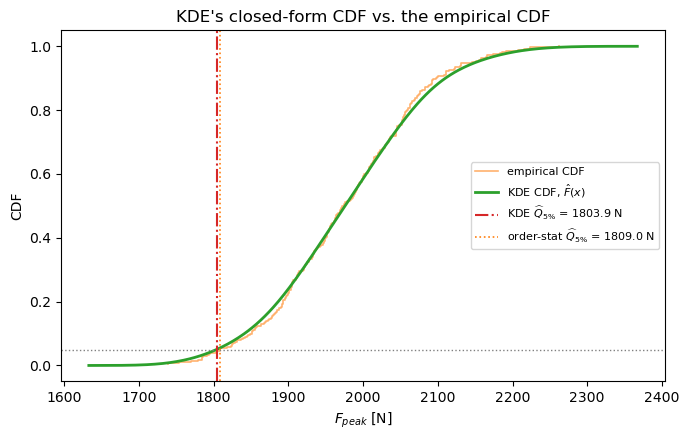

KDE Q5%:      1803.91 N  (-0.73% vs. analytical)


In [ ]:
q5_kde = kde_percentile(f_recon, h_best, p=0.05)

x_cdf = np.linspace(f_recon.min() - 3 * h_best, f_recon.max() + 3 * h_best, 400)
F_kde = kde_cdf(x_cdf, f_recon, h_best)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.step(f_sorted, ecdf, where="post", color="C1", lw=1.2, alpha=0.6, label="empirical CDF")  # C1: output, empirical (same staircase as Step 4's order-statistic figure)
ax.plot(x_cdf, F_kde, color="C2", lw=2, label=r"KDE CDF, $\hat F(x)$")  # C2: KDE-derived
ax.axhline(0.05, color="gray", ls=":", lw=1)
ax.axvline(q5_kde, color="C3", ls="-.", lw=1.5, label=f"KDE $\\widehat{{Q}}_{{5\\%}}$ = {q5_kde:.1f} N")
ax.axvline(q5_order_stat, color="C1", ls=":", lw=1.2, label=f"order-stat $\\widehat{{Q}}_{{5\\%}}$ = {q5_order_stat:.1f} N")
ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("CDF")
ax.set_title("KDE's closed-form CDF vs. the empirical CDF")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"KDE Q5%:      {q5_kde:.2f} N  ({(q5_kde - analytical_q5) / analytical_q5:+.2%} vs. analytical)")

Both curves rise from 0 to 1 across the same range, but the KDE's is smooth everywhere while the
empirical CDF is a staircase; the KDE crossing 0.05 measurably to the left of the staircase is
the smoothing shift Step 5 derives and checks next.

The cell below collects all three $Q_{5\%}$ estimates next to the analytical value.

In [26]:
print(f"{'estimator':28s}{'Q5% [N]':>12s}{'error vs. analytical':>24s}")
print("-" * 64)
print(f"{'analytical (exact)':28s}{analytical_q5:12.2f}{'--':>24s}")
print(f"{'plug-in (parametric)':28s}{q5_plugin:12.2f}{(q5_plugin - analytical_q5) / analytical_q5:24.3%}")
print(f"{'order statistic':28s}{q5_order_stat:12.2f}{(q5_order_stat - analytical_q5) / analytical_q5:24.3%}")
print(f"{'KDE (cross-validated h)':28s}{q5_kde:12.2f}{(q5_kde - analytical_q5) / analytical_q5:24.3%}")

estimator                        Q5% [N]    error vs. analytical
----------------------------------------------------------------
analytical (exact)               1817.16                      --
plug-in (parametric)             1813.75                 -0.188%
order statistic                  1809.03                 -0.447%
KDE (cross-validated h)          1803.91                 -0.729%


### Step 5 &ndash; why the three estimates differ

All three sit within a fraction of a percent of the analytical value and well within ordinary
Monte Carlo sampling noise at this $N$, but they are not identical, and the gaps between
them are not random: each is a direct consequence of what the estimator assumes.

**The plug-in is closest, and that is not a coincidence.** It fits only two numbers, $\hat\mu$
and $\hat\sigma$, but it uses **every one of the 280 points** to fit them, and it fits the *correct* family (the output really is Normal here). A
maximum-likelihood estimator for the correct parametric family is the most statistically
efficient estimator available; this is the one situation in the whole notebook where that
optimality actually applies.

**The order statistic is distribution-free, and pays for it in noise.** It assumes nothing about
the shape of $F_{peak}$'s distribution. As Step 4 showed directly on the empirical-CDF plot, that also means only the handful of sample points
that happen to land near the 5th percentile carry any information about it. With a few hundred
samples, "the handful of points near the 5th percentile" is a genuinely small handful, so this
estimator is noisier than the plug-in estimator, even though it is unbiased on average.

**KDE is biased low for a lower-tail percentile, and the size of that bias is derivable.**
Convolving the sample with a kernel of width $h$ is mathematically equivalent to adding
independent noise of standard deviation $h$ to every sample point, so the *KDE's own* estimated
variance is $\hat\sigma^2 + h^2$, not just $\hat\sigma^2$. Consequently, the smoothing genuinely widens the
estimated distribution. For a lower-tail percentile ($z_p<0$) a wider distribution has a lower
tail value, by approximately

$$
\Delta Q_p \approx z_p\,\hat\sigma\left(\sqrt{1 + (h/\hat\sigma)^2} - 1\right),
$$

which is checked directly below against the plug-in estimate.

In [27]:
predicted_shift = Z_P["5%"] * std_recon * (np.sqrt(1 + (h_best / std_recon) ** 2) - 1)
observed_shift = q5_kde - q5_plugin
print(f"Predicted KDE shift (smoothing-inflated variance):        {predicted_shift:+.2f} N")
print(f"Observed KDE shift (KDE Q5% - plug-in Q5%):               {observed_shift:+.2f} N")

Predicted KDE shift (smoothing-inflated variance):        -9.94 N
Observed KDE shift (KDE Q5% - plug-in Q5%):               -9.84 N


**The predicted and observed shifts agree to within a tenth of a Newton**, confirming the
derivation directly.

**When is KDE the right tool for a percentile, and when isn't it?** It depends on how deep the percentile is, and how many samples are available. If we want to resolve a very deep percentile with only a few samples, the order statistic might not have any points in the immediate neighborhood of that percentile, and KDE's smoothing would be necessary to get an approximate answer. Conversely, if we have a large number of samples and the percentile of interest is not too deep, the order statistic will have enough points to give a reliable estimate without the need for KDE. In this notebook's case, with $N=280$ and the 5th percentile being relatively shallow (about 14 points at or below it), the order statistic is sufficient and unbiased, while KDE introduces a bias. Furthermore it should be noted that **KDE's bias is not neutral.** For a lower-tail percentile, the smoothing derived above always pushes the estimate *down*, toward the conservative side for a design allowable. That is part of why it might be an acceptable estimate in many cases, even useful, price to pay in Catalanotti's setting (where nothing else is available), and an unnecessary one in this
notebook's, where the order statistic already does the job directly.

**All three estimates, including KDE's, still land inside Part 2's own $\pm1\%$ target.** The
$1813.75$&ndash;$1803.92$ N range spans about half a percent of the analytical value, well inside
the tolerance $N=280$ was explicitly sized for. This is a concrete confirmation that Part 2's
a-priori sample-size derivation delivered what it promised, independent of which of the three
estimators is trusted for the final number.

## Conclusion

This notebook built the first step of an uncertainty-quantification pipeline around one central
idea: build a trustworthy **distribution of the output**, $F_{peak}$, and read a design-relevant
percentile off it.

**What this notebook established:**

- **A random variable, its distribution, and the one case where the output distribution can be
  written down exactly.** $X_T$ became a Normal random variable (Part 1), explicitly named as a
  simplification, with the 5% CoV traced to [Sriramula & Chryssanthopoulos (2009)](https://doi.org/10.1016/j.compositesa.2009.08.020),
  the unphysical negative tail and the [Weibull (1951)](https://doi.org/10.1115/1.4010337)
  alternative both named honestly. Because $F_{peak}=A\cdot X_T$ is an *exactly linear* map, its
  entire distribution followed directly, with no Abaqus run needed &ndash; a special case, not the
  general rule.
- **A sample size derived analytically, exploited on both a tight and a loose tolerance, and
  verified against three actual random seeds.** Targeting a 1% relative standard error on the
  *plug-in* $\widehat{Q_{5\%}}$ gave $N=280$; comparing that against a looser 5% target showed that loosening the tolerance is a far bigger lever on cost than
  choosing a shallower percentile: a $5\times$ looser target cut the required $N$ by
  roughly $23\times$, versus only $\approx2.3\times$ between the 10th and 1st percentiles at
  fixed tolerance. Both the 1% target and the 5th percentile remain illustrative choices a real
  study would instead take from engineering judgement or a design code.
- **The Monte Carlo campaign itself, built and explained end to end inside this notebook, and
  verified against the exact small-strain formula.** One function to launch a single Abaqus run
  and save its history, one to run (and resume) the whole $N=280$-sample campaign, and NB1's own
  peak-reconstruction method, reused from a small shared module. The reconstructed peak matched
  the analytical mean and standard deviation to within a fraction of a percent (Step 1). Additionally, by comparing the simulated result against what a perfect, noiseless simulator would have produced for this *exact same* sampled draw, essentially all of that remaining gap turned out
  to be ordinary Monte Carlo sampling noise, not simulation or reconstruction error, confirming
  at population scale what NB1 already established for a single run.
- **Two ways of looking at the output distribution before trying to summarize it with a single
  number.** A histogram's bin-edge and bin-width choices were shown to be genuinely arbitrary
  (Step 2); kernel density estimation removed that arbitrariness, with its bandwidth chosen by
  leave-one-out cross-validation &ndash; a criterion explained from first principles, including
  why the effect of $h$ has to be seen before it can be trusted, why leaving each point out is
  essential, and why the score is a *sum of logs* (Step 3).
- **Three estimators of $Q_{5\%}$, and a concrete reason for each one's gap to the analytical
  value.** The plug-in formula matched most closely, because it is the maximum-likelihood
  estimator for the (here, provably correct) Normal family and uses every sample point. The
  distribution-free order statistic assumes nothing about the shape of the output but is noisier,
  since only the points near the tail inform it. KDE is a biased *tail-percentile* estimator, by a
  shift this notebook derived and then confirmed directly against the plug-in estimate: smoothing
  with a kernel of width $h$ inflates the estimated variance from $\hat\sigma^2$ to
  $\hat\sigma^2+h^2$, which pushes a lower-tail percentile down.

**Where this goes next.** This notebook sized $N$ a-priori and never had to ask *how* confident
it should be in the resulting estimate, because a closed form was available to check against the
whole time. NB3 removes that safety net: it repeats this campaign with no geometric nonlinearity as if we didn't know the closed form of the peak force distribution. Not knowing the answer in advance means not knowing $N$ in advance either, so NB3 introduces the **bootstrap**, which puts a confidence interval on an estimate using nothing but
the sample already in hand, and uses it to decide, campaign by campaign, when enough samples have
been run. Two campaigns are run: one with `nlgeom=OFF` and one with `nlgeom=ON`, where the mapping is truly nonlinear. At that point, NB3 can complete the
comparison NB1 started at a single point: how much (and why) does turning on geometric
nonlinearity move not just the mean, but also a given percentile.